# Paired MMC: figure_s15 inactive-virus classifier application

Apply the trained figure_s15 inactive-virus classifier (**story-20**, isotonic-calibrated **RF**,
**Caudoviricetes-only**) to paired **no-MMC ↔ MMC** libraries under:

- Legacy mvirs / benchmark: `results/uhvdb_toolkit/toolkit/referenceanalyze`
- New isolate run (Liang + PRJEB64565): `add_isolate_results/.../sracha_fastp_deacon_sylph_csvtk_seqkit_coverm_genecoverage`

Only pairs with sylph + CoverM + gene coverage on **both** sides are included (incomplete Nextflow samples are skipped automatically).

**Scope:** genomes with `ictv_class == "Caudoviricetes"` (matches training filter in
`meta["ictv_class_filter"]`).

**Ground truth (mapped onto HE6 bulk↔enriched labels)**
- **no-MMC ≈ bulk** (classifier features)
- **Induced / FP** if virus is detected in **MMC CoverM** and either (a) no host is detected in MMC sylph, or (b) host is detected and **PTH ≥ 2**
- **Uninducible / TP** otherwise (host present with PTH < 2, or virus not in MMC)
- Detection universe = **no-MMC CoverM species detections only** (labels from MMC)

**Call rule:** `P(inactive) ≥ meta["thresh_90"]` (Liang OOF **95% precision** cutoff; ~0.873 for story-20 RF).
Joblib keys `thresh_90` / `thresh_75` / `thresh_50` map to 95% / 90% / 85% precision.

**Analyses**
1. Precision / recall (PR + ROC) on no-MMC features
2. Proportion called uninducible — no-MMC vs MMC features
3. VHR precision / recall (cascade) — before vs after filter
4. VIBRANT high-quality vs inducible (FP)
5. Insertion sequence (Bakta `IS:` / sample coverage) vs uninducible (TP)

Outputs → `paired_mmc_results/`


In [41]:
### paths, imports, helpers
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)

plt.rcParams.update({"font.size": 12})

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
ANALYSIS = Path(".").resolve()
if not (ANALYSIS / "results/uhvdb_toolkit/toolkit/referenceanalyze").exists():
    ANALYSIS = Path(
        "/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/"
        "uhvdb-manuscript-update/mmc_activity_analysis"
    )
ROOT = ANALYSIS.parents[1]
FIG_S15 = ROOT / "uhvdb-manuscript/figure_s15"
REF = ANALYSIS / "results/uhvdb_toolkit/toolkit/referenceanalyze"
REF_ISOLATE = (
    ANALYSIS
    / "add_isolate_results/uhvdb_toolkit/toolkit/referenceanalyze"
    / "sracha_fastp_deacon_sylph_csvtk_seqkit_coverm_genecoverage"
)
# Legacy spring_* layout (mvirs benchmark) + flat toolkit2 isolate layout
SYLPH_DIRS = [REF / "spring_sylph", REF_ISOLATE]
COVERM_DIRS = [REF / "spring_coverm", REF_ISOLATE]
GENE_DIRS = [REF / "uhvdb_genecoverage", REF_ISOLATE]
# Keep single-dir aliases for any leftover references
SYLPH_DIR = SYLPH_DIRS[0]
COVERM_DIR = COVERM_DIRS[0]
GENE_DIR = GENE_DIRS[0]
MODEL_DIR = FIG_S15
METADATA = ROOT / "uhvdb-manuscript/figure_s18/uhvdb_v5_final_metadata_v2.tsv.gz"
FIG1 = ROOT / "uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2"
PHIST = FIG1 / "uhvdb_phisthost.tsv.gz"
CRISPR = FIG1 / "uhvdb_crisprhost.tsv.gz"
GTDB = ROOT / "uhvdb-manuscript/figure_4/sylph_tax/gtdb_r214_metadata.tsv.gz"
OUT_DIR = ANALYSIS / "paired_mmc_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENE_BREADTH_THRESHOLD = 0.8
PTH_FP_THRESHOLD = 2.0  # PTH >= 2 in MMC → FP (≈ bulk+enriched)
VHR_THRESHOLDS = [0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.5]
META_HALLMARK_COLLISION_COLS = (
    "n_hallmarks",
    "mcp_hallmark",
    "terl_hallmark",
    "portal_hallmark",
)

GENE_PROP_COLS = [
    "med_prop_capsid_packaging",
    "med_prop_dna_metabolism",
    "med_prop_tail",
    "med_prop_lysis",
    "med_prop_connector",
    "med_prop_transcription",
    "med_prop_integration",
    "med_prop_amg_host_takeover",
    "med_mcp_hallmark",
    "med_portal_hallmark",
    "med_terL_hallmark",
    "med_n_hallmarks",
]
PROF_FEAT_COLS = [
    "log_True_cov",
    "log_tax_abund",
    "log_seq_abund",
    "Adjusted_ANI",
    "Naive_ANI",
    "containment_frac",
    "Eff_lambda_ord",
    "ANI_interval_width",
    "Median_cov",
    "Mean_cov_geq1",
    "kmers_reassigned",
    "cov_evenness",
    "True_cov_rank",
    "tax_abund_rank",
    "ani",
]
GENE_STAT_COLS = [
    "gene_breadth_mean",
    "gene_breadth_std",
    "gene_breadth_cv",
    "frac_genes_breadth_ge_0_5",
    "frac_genes_breadth_ge_0_8",
    "gene_mean_depth_mean",
    "gene_mean_depth_std",
    "gene_occupancy",
    "n_struct_genes",
]


def with_bio_group_flags(df: pl.DataFrame) -> pl.DataFrame:
    cols = df.columns
    prep = []
    for name in ("pharokka_category", "phold_category", "empathi_annot", "pharokka_annot"):
        if name in cols:
            prep.append(pl.col(name).fill_null(""))
        else:
            prep.append(pl.lit("").alias(name))
    out = df.with_columns(prep).with_columns(
        [
            pl.col("empathi_annot")
            .str.split("|")
            .list.get(0, null_on_oob=True)
            .fill_null("")
            .alias("empathi_token0"),
            pl.col("empathi_annot")
            .str.split("|")
            .list.get(1, null_on_oob=True)
            .fill_null("")
            .alias("empathi_token1"),
        ]
    )
    return out.with_columns(
        [
            (
                (pl.col("pharokka_category") == "head and packaging")
                | pl.col("phold_category").str.contains("(?i)head|capsid|portal|terminase")
                | (pl.col("empathi_token0") == "pvp")
                | (pl.col("empathi_token0") == "packaging_assembly")
                | pl.col("empathi_token1").is_in(
                    ["capsid", "terminase", "portal", "head-tail_joining"]
                )
            ).alias("is_capsid_packaging"),
            (
                (pl.col("pharokka_category") == "DNA, RNA and nucleotide metabolism")
                | (pl.col("empathi_token0") == "DNA-associated")
                | (pl.col("empathi_token0") == "RNA-associated")
                | pl.col("empathi_token1").is_in(
                    ["nuclease", "annealing", "DNA_polymerase", "helicase"]
                )
            ).alias("is_dna_metabolism"),
            (
                (pl.col("pharokka_category") == "tail")
                | pl.col("phold_category").str.contains(r"(?i)\btail\b")
                | (pl.col("empathi_token1") == "tail")
            ).alias("is_tail"),
            (
                (pl.col("pharokka_category") == "lysis")
                | pl.col("phold_category").str.contains("(?i)lysis|holin|endolysin")
                | (pl.col("empathi_token0") == "lysis")
                | (pl.col("empathi_token0") == "cell_wall_depolymerase")
                | pl.col("empathi_token1").is_in(["lysis", "holin"])
            ).alias("is_lysis"),
            (
                (pl.col("pharokka_category") == "connector")
                | pl.col("phold_category").str.contains("(?i)connector|head-tail|head–tail")
            ).alias("is_connector"),
            (
                (pl.col("pharokka_category") == "transcription regulation")
                | (pl.col("empathi_token0") == "transcriptional_regulator")
                | (pl.col("empathi_token1") == "transcriptional_regulator")
            ).alias("is_transcription"),
            (
                (pl.col("pharokka_category") == "integration and excision")
                | pl.col("phold_category").str.contains("(?i)integrase|integration")
                | (pl.col("empathi_token1") == "integration")
            ).alias("is_integration"),
            (
                (
                    pl.col("pharokka_category")
                    == "moron, auxiliary metabolic gene and host takeover"
                )
                | pl.col("phold_category").str.contains(
                    r"(?i)auxiliary metabolic|host takeover|moron|anti[- ]?defen[cs]e"
                )
                | pl.col("empathi_token0").is_in(
                    ["amg", "auxiliary_metabolic", "host_takeover", "moron", "anti-defense"]
                )
                | pl.col("empathi_token1").is_in(
                    ["amg", "auxiliary_metabolic", "host_takeover", "moron", "anti-defense"]
                )
            ).alias("is_amg_host_takeover"),
        ]
    )


def normalize_sample_id(sample_id: str) -> str:
    return re.sub(r"^mmvirs_", "mvirs_", sample_id)


def mmc_status_and_pair(sample_id: str):
    sid = normalize_sample_id(sample_id)
    if sid.endswith("_no_mmc"):
        return "no_mmc", sid[: -len("_no_mmc")]
    if sid.endswith("_mmc"):
        return "mmc", sid[: -len("_mmc")]
    return None, sid


def sample_id_from_path(path: Path) -> str:
    name = path.name
    for suffix in (
        ".gene_coverage.tsv.gz",
        ".gene_coverage.tsv",
        ".depth.tsv.gz",
        ".depth.tsv",
        ".profile.tsv",
    ):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return path.stem


def _sample_aliases(sample_id: str) -> list[str]:
    sid = normalize_sample_id(sample_id)
    aliases = [sample_id, sid]
    if sample_id.startswith("mvirs_"):
        aliases.append(sample_id.replace("mvirs_", "mmvirs_", 1))
    if sid.startswith("mvirs_"):
        aliases.append(sid.replace("mvirs_", "mmvirs_", 1))
    # preserve order, drop dups
    out, seen = [], set()
    for a in aliases:
        if a not in seen:
            out.append(a)
            seen.add(a)
    return out


def resolve_profile_path(sample_id: str) -> Path | None:
    for sid in _sample_aliases(sample_id):
        for d in SYLPH_DIRS:
            if not d.exists():
                continue
            p = d / f"{sid}.profile.tsv"
            if p.exists():
                return p
    return None


def resolve_depth_path(sample_id: str) -> Path | None:
    for sid in _sample_aliases(sample_id):
        for d in COVERM_DIRS:
            if not d.exists():
                continue
            for name in (f"{sid}.depth.tsv.gz", f"{sid}.depth.tsv"):
                p = d / name
                if p.exists():
                    return p
    return None


def resolve_gene_path(sample_id: str) -> Path | None:
    for sid in _sample_aliases(sample_id):
        for d in GENE_DIRS:
            if not d.exists():
                continue
            for name in (f"{sid}.gene_coverage.tsv.gz", f"{sid}.gene_coverage.tsv"):
                p = d / name
                if p.exists():
                    return p
    return None


def discover_complete_pairs():
    """Pairs with sylph+coverm+gene for both no_mmc and mmc (legacy + isolate runs)."""
    sylph, coverm, gene = set(), set(), set()
    for d in SYLPH_DIRS:
        if d.exists():
            sylph |= {sample_id_from_path(p) for p in d.glob("*.profile.tsv")}
    for d in COVERM_DIRS:
        if not d.exists():
            continue
        coverm |= {sample_id_from_path(p) for p in d.glob("*.depth.tsv")}
        coverm |= {sample_id_from_path(p) for p in d.glob("*.depth.tsv.gz")}
    for d in GENE_DIRS:
        if d.exists():
            gene |= {sample_id_from_path(p) for p in d.glob("*.gene_coverage.tsv.gz")}

    by = {}
    for sid in sylph | coverm | gene:
        st, pair = mmc_status_and_pair(sid)
        if st is None:
            continue
        by.setdefault(pair, {}).setdefault(st, set())
        if sid in sylph or resolve_profile_path(f"{pair}_{st}") is not None:
            by[pair][st].add("sylph")
        if sid in coverm or resolve_depth_path(f"{pair}_{st}") is not None:
            by[pair][st].add("coverm")
        if resolve_gene_path(f"{pair}_{st}") is not None or sid in gene:
            by[pair][st].add("gene")
    need = {"sylph", "coverm", "gene"}
    return sorted(
        p
        for p, d in by.items()
        if need <= d.get("no_mmc", set()) and need <= d.get("mmc", set())
    )



def is_mmc_sid(col: str = "sample_id") -> pl.Expr:
    """True for *_mmc but not *_no_mmc (str.ends_with('_mmc') also matches no_mmc)."""
    return pl.col(col).str.ends_with("_mmc") & ~pl.col(col).str.ends_with("_no_mmc")


def is_no_mmc_sid(col: str = "sample_id") -> pl.Expr:
    return pl.col(col).str.ends_with("_no_mmc")

def load_depth(path: Path, sample_id: str, group: str) -> pl.DataFrame:
    raw = pl.read_csv(path, separator="\t")
    cols = raw.columns
    rename = {
        cols[0]: "contig_id",
        cols[1]: "trimmed_mean",
        cols[2]: "mean",
        cols[3]: "variance",
        cols[4]: "covered_bases",
        cols[5]: "length",
    }
    return (
        raw.rename(rename)
        .with_columns(
            [
                pl.col("trimmed_mean").cast(pl.Float64),
                pl.col("mean").cast(pl.Float64),
                pl.col("variance").cast(pl.Float64),
                pl.col("covered_bases").cast(pl.Float64),
                pl.col("length").cast(pl.Float64),
                pl.lit(sample_id).alias("sample_id"),
                pl.lit(group).alias("group"),
            ]
        )
        .with_columns(
            [
                (pl.col("covered_bases") / pl.col("length")).alias("breadth"),
                (1 - math.e ** (-0.833 * pl.col("mean"))).alias("expected_breadth"),
            ]
        )
        .with_columns(
            pl.when(pl.col("expected_breadth") > 1e-6)
            .then(pl.col("breadth") / pl.col("expected_breadth"))
            .otherwise(None)
            .alias("breadth_ratio")
        )
    )


def gene_prop_agg(df: pl.DataFrame) -> pl.DataFrame:
    return (
        with_bio_group_flags(df)
        .group_by(["sample_id", "genomovar_rep"])
        .agg(
            [
                pl.len().alias("n_genes_covered"),
                pl.col("is_capsid_packaging").mean().alias("prop_capsid_packaging"),
                pl.col("is_dna_metabolism").mean().alias("prop_dna_metabolism"),
                pl.col("is_tail").mean().alias("prop_tail"),
                pl.col("is_lysis").mean().alias("prop_lysis"),
                pl.col("is_connector").mean().alias("prop_connector"),
                pl.col("is_transcription").mean().alias("prop_transcription"),
                pl.col("is_integration").mean().alias("prop_integration"),
                pl.col("is_amg_host_takeover").mean().alias("prop_amg_host_takeover"),
                (
                    ((pl.col("pharokka_annot") == "major head protein").sum() >= 1)
                    | ((pl.col("phold_category") == "major head protein").sum() >= 1)
                    | ((pl.col("empathi_annot") == "pvp|capsid|major_capsid").sum() >= 1)
                )
                .cast(pl.UInt32)
                .alias("mcp_hallmark"),
                (
                    ((pl.col("pharokka_annot") == "terminase large subunit").sum() >= 1)
                    | ((pl.col("phold_category") == "terminase large subunit").sum() >= 1)
                    | (
                        (
                            pl.col("empathi_annot")
                            == "DNA-associated|terminase|packaging_assembly"
                        ).sum()
                        >= 1
                    )
                )
                .cast(pl.UInt32)
                .alias("terl_hallmark"),
                (
                    ((pl.col("pharokka_annot") == "portal protein").sum() >= 1)
                    | ((pl.col("phold_category") == "portal protein").sum() >= 1)
                    | ((pl.col("empathi_annot") == "pvp|portal").sum() >= 1)
                )
                .cast(pl.UInt32)
                .alias("portal_hallmark"),
            ]
        )
        .with_columns(
            (pl.col("mcp_hallmark") + pl.col("terl_hallmark") + pl.col("portal_hallmark")).alias(
                "n_hallmarks"
            )
        )
    )


def _parse_containment_frac(s):
    if s is None or not isinstance(s, str) or "/" not in s:
        return None
    try:
        a, b = s.split("/", 1)
        a, b = float(a), float(b)
        return float(a / b) if b else None
    except Exception:
        return None


def _parse_ani_width(s):
    if s is None or not isinstance(s, str) or str(s).startswith("NA") or "-" not in str(s):
        return None
    try:
        lo, hi = str(s).split("-", 1)
        return float(hi) - float(lo)
    except Exception:
        return None


def with_viral_gene_frac(df: pl.DataFrame) -> pl.DataFrame:
    """Story-20 derived feature: CheckV viral_genes / (viral_genes + host_genes)."""
    return df.with_columns(
        (
            pl.col("viral_genes").cast(pl.Float64, strict=False)
            / (
                pl.col("viral_genes").cast(pl.Float64, strict=False)
                + pl.col("host_genes").cast(pl.Float64, strict=False)
            )
        ).alias("viral_gene_frac")
    )


def pr_curve_for_plot(y_true, proba, min_predicted: int = 20):
    """PR coordinates for figures.

    sklearn appends (recall=0, precision=1) with no threshold, and the first
    few high-score isotonic ties have too few calls for a stable precision.
    Drop those, then extend left to recall=0 at the first stable precision so
    the curve does not start with a tiny-N cliff. Report AUPRC from
    average_precision_score on the full scores, not this trim.
    """
    y = np.asarray(y_true).astype(int)
    p = np.asarray(proba, dtype=float)
    prec, rec, _thr = precision_recall_curve(y, p)
    prec, rec = np.asarray(prec[:-1], dtype=float), np.asarray(rec[:-1], dtype=float)
    n_pos = max(int(y.sum()), 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        n_pred = rec * n_pos / prec
    keep = np.isfinite(n_pred) & (n_pred >= min_predicted)
    if keep.any():
        rec, prec = rec[keep], prec[keep]
    # sklearn returns decreasing recall; extend to R=0 at the first *stable*
    # high-score precision (last remaining point), not the prevalence end.
    rec = np.r_[rec, 0.0]
    prec = np.r_[prec, prec[-1]]
    return rec, prec


def majority_host(df: pl.DataFrame, col: str) -> pl.DataFrame:
    return (
        df.filter(pl.col(col).is_not_null())
        .group_by(["species_cluster_id", col])
        .agg(pl.len().alias("n"))
        .sort(["species_cluster_id", "n", col], descending=[False, True, False])
        .unique("species_cluster_id", maintain_order=True)
        .select(["species_cluster_id", col])
    )


def elevated_prop_curve(frame: pd.DataFrame, thresholds) -> pd.DataFrame:
    """Precision/recall of VHR ≥ t as a call for induced (pr_cat==FP / PTH_mmc≥2).

    Precision = n_fp / n among detections with phage_host_ratio ≥ t
    Recall    = n_fp / n_fp_total in ``frame``
    """
    n_fp_total = int((frame["pr_cat"] == "FP").sum())
    rows = []
    for t in thresholds:
        in_thr = frame.loc[frame["phage_host_ratio"] >= t]
        n = len(in_thr)
        n_fp = int((in_thr["pr_cat"] == "FP").sum())
        precision = (n_fp / n) if n else None
        recall = (n_fp / n_fp_total) if n_fp_total else None
        rows.append(
            {
                "vhr_threshold": t,
                "n_no_mmc": n,
                "n_pth_mmc_ge2": n_fp,
                "n_fp_total": n_fp_total,
                "precision": precision,
                "recall": recall,
                # alias kept for downstream TSV compatibility
                "prop_pth_mmc_ge2": precision,
            }
        )
    return pd.DataFrame(rows)


print("ANALYSIS:", ANALYSIS)
print("REF:", REF)
print("REF_ISOLATE:", REF_ISOLATE)
print("OUT_DIR:", OUT_DIR)


ANALYSIS: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis
REF: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/results/uhvdb_toolkit/toolkit/referenceanalyze
REF_ISOLATE: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/add_isolate_results/uhvdb_toolkit/toolkit/referenceanalyze/sracha_fastp_deacon_sylph_csvtk_seqkit_coverm_genecoverage
OUT_DIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/paired_mmc_results


In [42]:
### load model, discover pairs, load CoverM / gene / sylph + build features
meta = joblib.load(MODEL_DIR / "phage_model_metadata_full.joblib")
pipeline = joblib.load(MODEL_DIR / "phage_activity_model_full.joblib")
numeric_cols = list(meta["numeric_cols"])
thr = float(meta["thresh_90"])
ICTV_CLASS_FILTER = meta.get("ictv_class_filter", "Caudoviricetes")
if ICTV_CLASS_FILTER != "Caudoviricetes":
    raise ValueError(
        f"Expected Caudoviricetes model; got ictv_class_filter={ICTV_CLASS_FILTER!r}"
    )
print(
    f"features={len(numeric_cols)}  feature_set={meta.get('feature_set')}  "
    f"learner={meta.get('learner')}  thresh_90={thr:.4f}  "
    f"ictv_class_filter={ICTV_CLASS_FILTER}  PTH_FP_THRESHOLD={PTH_FP_THRESHOLD}"
)

pairs = discover_complete_pairs()
if not pairs:
    raise SystemExit(f"No complete no_mmc↔mmc pairs under {REF} or {REF_ISOLATE}")
n_mvirs = sum(p.startswith("mvirs_") for p in pairs)
n_liang = sum(p.startswith("liang_") for p in pairs)
n_cc = sum(p.startswith("cc_") for p in pairs)
print(f"pairs={len(pairs)}  mvirs={n_mvirs}  liang={n_liang}  cc={n_cc}")
print("pairs:", pairs)

uhvdb_cols = pl.read_csv(METADATA, separator="\t", n_rows=0).columns
uhvdb_full = pl.read_csv(METADATA, separator="\t")
uhvdb = uhvdb_full.drop([c for c in META_HALLMARK_COLLISION_COLS if c in uhvdb_cols])
id_map = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id"])
    .unique("uhvdb_id")
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
)

depth_lst, gene_raw_lst, prof_lst = [], [], []
for g in pairs:
    for kind in ("no_mmc", "mmc"):
        sid = f"{g}_{kind}"
        depth_path = resolve_depth_path(sid)
        gene_path = resolve_gene_path(sid)
        prof_path = resolve_profile_path(sid)
        if depth_path is None:
            raise FileNotFoundError(f"Missing CoverM depth for {sid}")
        if gene_path is None:
            raise FileNotFoundError(f"Missing gene coverage for {sid}")
        if prof_path is None:
            raise FileNotFoundError(f"Missing sylph profile for {sid}")
        depth_lst.append(load_depth(depth_path, sid, g))
        gene_raw_lst.append(
            pl.read_csv(gene_path, separator="\t")
            .filter(pl.col("genomovar_rep").str.starts_with("UHVDB-"))
            .with_columns(pl.lit(sid).alias("sample_id"))
        )
        prof_lst.append(
            pl.read_csv(prof_path, separator="\t")
            .filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Contig_name").alias("uhvdb_id"),
                    pl.col("True_cov").cast(pl.Float64),
                    pl.col("Taxonomic_abundance").cast(pl.Float64).alias("tax_abund"),
                    pl.col("Sequence_abundance").cast(pl.Float64).alias("seq_abund"),
                    pl.col("Adjusted_ANI").cast(pl.Float64),
                    pl.col("Naive_ANI").cast(pl.Float64),
                    pl.col("Median_cov").cast(pl.Float64),
                    pl.col("Mean_cov_geq1").cast(pl.Float64),
                    pl.col("kmers_reassigned").cast(pl.Float64),
                    pl.col("Containment_ind").cast(pl.Utf8),
                    pl.col("Eff_lambda").cast(pl.Utf8),
                    pl.col("ANI_5-95_percentile").cast(pl.Utf8).alias("ANI_5_95"),
                ]
            )
        )
coverm_df = pl.concat(depth_lst)
gene_raw = pl.concat(gene_raw_lst)
prof_raw = pl.concat(prof_lst)

# ---------------------------------------------------------------------------
# Host tables for PTH / VHR on MMC (and later no-MMC enrichment curves)
# ---------------------------------------------------------------------------
uhvdb_genomovar_host = (
    pl.read_csv(PHIST, separator="\t")[
        ["uhvdb_id", "total_connections", "rank", "agreement", "consensus_taxonomy"]
    ]
    .join(
        pl.read_csv(CRISPR, separator="\t")[
            ["uhvdb_id", "total_connections", "rank", "agreement", "top_taxonomy"]
        ],
        on=["uhvdb_id", "rank"],
        how="full",
        suffix="_crispr",
    )
    .fill_null(0)
    .with_columns(pl.col("consensus_taxonomy").str.replace(r"^(s|g|f)__", ""))
    .with_columns(
        [
            pl.when(pl.col("consensus_taxonomy") == pl.col("top_taxonomy"))
            .then(pl.col("consensus_taxonomy"))
            .when(
                (pl.col("total_connections") * pl.col("agreement"))
                >= (pl.col("total_connections_crispr") * pl.col("agreement_crispr"))
            )
            .then(pl.col("consensus_taxonomy"))
            .otherwise(pl.col("top_taxonomy"))
            .alias("final_taxonomy"),
            pl.coalesce(["rank", "rank_crispr"]).alias("final_rank"),
            pl.coalesce(["uhvdb_id", "uhvdb_id_crispr"]).alias("final_id"),
        ]
    )
    .group_by("final_id")
    .agg(
        [
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "species")
            .first()
            .alias("final_species"),
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "genus")
            .first()
            .alias("final_genus"),
            pl.col("final_taxonomy")
            .filter(pl.col("final_rank") == "family")
            .first()
            .alias("final_family"),
        ]
    )
    .rename({"final_id": "uhvdb_id"})
)
gv = (
    uhvdb_full.select(["uhvdb_id", "species_cluster_id", "genomovar_rep", "species_rep"])
    .filter(pl.col("uhvdb_id") == pl.col("genomovar_rep"))
    .select(["uhvdb_id", "species_cluster_id", "species_rep"])
    .unique()
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .join(uhvdb_genomovar_host, on="uhvdb_id", how="left")
)
host = (
    gv.select(["species_cluster_id", "species_rep"])
    .unique()
    .join(majority_host(gv, "final_species"), on="species_cluster_id", how="left")
    .join(majority_host(gv, "final_genus"), on="species_cluster_id", how="left")
    .join(majority_host(gv, "final_family"), on="species_cluster_id", how="left")
)

gtdb = (
    pl.read_csv(GTDB, separator="\t", has_header=False, new_columns=["accession", "lineage"])
    .with_columns(
        [
            pl.col("lineage").str.extract(r"g__([^;]+)", 1).alias("genus"),
            pl.col("lineage").str.extract(r"s__([^;]+)", 1).alias("species"),
            pl.col("lineage").str.extract(r"f__([^;]+)", 1).alias("family"),
        ]
    )
    .unique("accession")
)


def compute_cascade_vhr(sample_ids):
    """Cascade PTH per sample × species_cluster (species → genus singleton → family singleton)."""
    virus_rows, bac_rows = [], []
    for sid in sample_ids:
        path = resolve_profile_path(sid)
        if path is None:
            continue
        df = pl.read_csv(path, separator="\t")
        virus_rows.append(
            df.filter(pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Contig_name").alias("uhvdb_id"),
                    pl.col("Taxonomic_abundance").cast(pl.Float64).alias("virus_tax_abund"),
                ]
            )
            .join(id_map, on="uhvdb_id", how="inner")
            .group_by(["sample_id", "species_cluster_id"])
            .agg(pl.col("virus_tax_abund").max())
        )
        bac_rows.append(
            df.filter(~pl.col("Contig_name").str.starts_with("UHVDB-"))
            .with_columns(
                [
                    pl.lit(sid).alias("sample_id"),
                    pl.col("Genome_file")
                    .cast(pl.Utf8)
                    .str.extract(r"(GC[AF]_\d+\.\d+)", 1)
                    .alias("accession"),
                    pl.col("Taxonomic_abundance").cast(pl.Float64).alias("host_tax_abund"),
                ]
            )
            .filter(pl.col("accession").is_not_null())
            .join(
                gtdb.select(["accession", "genus", "species", "family"]),
                on="accession",
                how="left",
            )
            .filter(pl.col("genus").is_not_null())
            .group_by(["sample_id", "species", "genus", "family"])
            .agg(pl.col("host_tax_abund").sum())
        )
    viruses = (
        pl.concat(virus_rows)
        .join(
            host.select(
                ["species_cluster_id", "final_species", "final_genus", "final_family"]
            ),
            on="species_cluster_id",
            how="left",
        )
        .with_columns(
            [
                pl.col("final_genus").alias("host_genus"),
                pl.col("final_family").alias("host_family"),
            ]
        )
    )
    bac_sylph = pl.concat(bac_rows)

    species_hits = (
        viruses.filter(pl.col("final_species").is_not_null() & (pl.col("virus_tax_abund") > 0))
        .join(
            bac_sylph.select(["sample_id", "species", "host_tax_abund"]),
            left_on=["sample_id", "final_species"],
            right_on=["sample_id", "species"],
            how="inner",
        )
        .with_columns(pl.lit("species_codetected").alias("host_match_method"))
    )
    matched_keys = species_hits.select(["sample_id", "species_cluster_id"]).unique()
    genus_singleton = (
        bac_sylph.group_by(["sample_id", "genus"])
        .agg(
            [
                pl.len().alias("n_species"),
                pl.col("species").first().alias("species"),
                pl.col("host_tax_abund").first().alias("host_tax_abund"),
            ]
        )
        .filter(pl.col("n_species") == 1)
    )
    genus_hits = (
        viruses.join(matched_keys, on=["sample_id", "species_cluster_id"], how="anti")
        .filter(pl.col("host_genus").is_not_null() & (pl.col("virus_tax_abund") > 0))
        .join(
            genus_singleton.select(["sample_id", "genus", "species", "host_tax_abund"]),
            left_on=["sample_id", "host_genus"],
            right_on=["sample_id", "genus"],
            how="inner",
        )
        .with_columns(pl.lit("genus_singleton").alias("host_match_method"))
    )
    matched_keys2 = pl.concat(
        [matched_keys, genus_hits.select(["sample_id", "species_cluster_id"]).unique()]
    ).unique()
    family_singleton = (
        bac_sylph.group_by(["sample_id", "family"])
        .agg(
            [
                pl.len().alias("n_species"),
                pl.col("species").first().alias("species"),
                pl.col("host_tax_abund").first().alias("host_tax_abund"),
            ]
        )
        .filter(pl.col("n_species") == 1)
    )
    family_hits = (
        viruses.join(matched_keys2, on=["sample_id", "species_cluster_id"], how="anti")
        .filter(pl.col("host_family").is_not_null() & (pl.col("virus_tax_abund") > 0))
        .join(
            family_singleton.select(["sample_id", "family", "species", "host_tax_abund"]),
            left_on=["sample_id", "host_family"],
            right_on=["sample_id", "family"],
            how="inner",
        )
        .with_columns(pl.lit("family_singleton").alias("host_match_method"))
    )
    vhr_cols = ["sample_id", "species_cluster_id", "virus_tax_abund", "host_tax_abund", "host_match_method"]
    vhr_cascade = (
        pl.concat(
            [
                species_hits.select(vhr_cols),
                genus_hits.select(vhr_cols),
                family_hits.select(vhr_cols),
            ]
        )
        .with_columns(
            (pl.col("virus_tax_abund") / pl.col("host_tax_abund")).alias("phage_host_ratio")
        )
        .filter(pl.col("host_tax_abund") > 0)
        .sort(
            ["sample_id", "species_cluster_id", "virus_tax_abund"],
            descending=[False, False, True],
        )
        .unique(["sample_id", "species_cluster_id"], keep="first")
    )
    combined = (
        vhr_cascade.select(["sample_id", "species_cluster_id", "phage_host_ratio", "host_match_method"])
        .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
        .rename({"phage_host_ratio": "vhr_cascade"})
        .with_columns(pl.col("vhr_cascade").alias("phage_host_ratio"))
    )
    return combined, viruses, bac_sylph, vhr_cascade


mmc_sids = [f"{g}_mmc" for g in pairs]
no_mmc_sids = [f"{g}_no_mmc" for g in pairs]
vhr_mmc_combined, _, _, _ = compute_cascade_vhr(mmc_sids)
vhr_no_mmc_combined, _, _, _ = compute_cascade_vhr(no_mmc_sids)

# Primary label PTH = cascade on MMC.
# Host detected in MMC ⇔ species has a VHR row (host taxon matched in sylph).
# Induced / elevated if:
#   - host detected and PTH >= 2, OR
#   - virus detected in MMC CoverM and no host detected (treat as PTH >= 2).
pth_mmc = vhr_mmc_combined.select(
    [
        pl.col("sample_id").str.replace(r"_mmc$", "").alias("group"),
        "species_cluster_id",
        pl.col("vhr_cascade").alias("pth_mmc"),
        "vhr_cascade",
        pl.lit(True).alias("host_detected_mmc"),
    ]
)

print(
    "MMC PTH among host-matched MMC VHR species:",
    pth_mmc.select(
        [
            pl.len().alias("n_host_matched"),
            (pl.col("pth_mmc") >= PTH_FP_THRESHOLD).sum().alias("n_pth_ge2"),
            (pl.col("pth_mmc") < PTH_FP_THRESHOLD).sum().alias("n_pth_lt2"),
        ]
    )
)

def _assign_mmc_labels(det: pl.DataFrame) -> pl.DataFrame:
    """Attach PTH / host flags and elevated_mmc + pr_cat for CoverM detections."""
    return (
        det.join(
            pth_mmc.select(
                ["group", "species_cluster_id", "pth_mmc", "host_detected_mmc", "vhr_cascade"]
            ),
            on=["group", "species_cluster_id"],
            how="left",
        )
        .with_columns(pl.col("host_detected_mmc").fill_null(False))
        .with_columns(
            # Virus is present in this CoverM table by construction.
            pl.when(pl.col("host_detected_mmc"))
            .then(pl.col("pth_mmc") >= PTH_FP_THRESHOLD)
            .otherwise(True)  # MMC virus, no host → treat as PTH >= 2
            .alias("elevated_mmc")
        )
        .with_columns(
            pl.when(pl.col("host_detected_mmc"))
            .then(pl.col("pth_mmc"))
            .otherwise(pl.lit(float(PTH_FP_THRESHOLD)))  # sentinel for virus-no-host
            .alias("pth_mmc")
        )
        .with_columns(
            pl.when(pl.col("elevated_mmc"))
            .then(pl.lit("FP"))
            .otherwise(pl.lit("TP"))
            .alias("pr_cat")
        )
    )


# Labels from CoverM no_mmc detections + MMC induction rule
no_mmc_det = _assign_mmc_labels(
    coverm_df.filter(is_no_mmc_sid())
    .filter(pl.col("breadth_ratio") > 0)
    .filter(pl.col("contig_id").str.starts_with("UHVDB-"))
    .join(uhvdb, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .unique(["species_cluster_id", "group"], keep="first")
)

# For no-MMC rows, virus must also be detected in the paired MMC CoverM to count
# as "virus-no-host → elevated". If absent from MMC entirely, not elevated.
mmc_virus_keys = (
    coverm_df.filter(is_mmc_sid())
    .filter(pl.col("breadth_ratio") > 0)
    .filter(pl.col("contig_id").str.starts_with("UHVDB-"))
    .join(uhvdb, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .select(["group", "species_cluster_id"])
    .unique()
    .with_columns(pl.lit(True).alias("virus_detected_mmc"))
)
no_mmc_det = (
    no_mmc_det.join(mmc_virus_keys, on=["group", "species_cluster_id"], how="left")
    .with_columns(pl.col("virus_detected_mmc").fill_null(False))
    .with_columns(
        pl.when(pl.col("host_detected_mmc"))
        .then(pl.col("pth_mmc") >= PTH_FP_THRESHOLD)
        .when(pl.col("virus_detected_mmc"))
        .then(True)
        .otherwise(False)
        .alias("elevated_mmc")
    )
    .with_columns(
        pl.when(pl.col("host_detected_mmc"))
        .then(pl.col("pth_mmc"))
        .when(pl.col("virus_detected_mmc"))
        .then(pl.lit(float(PTH_FP_THRESHOLD)))
        .otherwise(0.0)
        .alias("pth_mmc")
    )
    .with_columns(
        pl.when(pl.col("elevated_mmc"))
        .then(pl.lit("FP"))
        .otherwise(pl.lit("TP"))
        .alias("pr_cat")
    )
)

print(
    "no-MMC label rule breakdown:",
    no_mmc_det.select(
        [
            pl.len().alias("n"),
            pl.col("host_detected_mmc").sum().alias("n_host_in_mmc"),
            pl.col("virus_detected_mmc").sum().alias("n_virus_in_mmc"),
            (
                (~pl.col("host_detected_mmc")) & pl.col("virus_detected_mmc")
            ).sum().alias("n_virus_no_host"),
            pl.col("elevated_mmc").sum().alias("n_elevated_fp"),
        ]
    ),
)

# MMC detections for FN / MMC-feature panels (virus present by construction)
mmc_det = _assign_mmc_labels(
    coverm_df.filter(is_mmc_sid())
    .filter(pl.col("breadth_ratio") > 0)
    .filter(pl.col("contig_id").str.starts_with("UHVDB-"))
    .join(uhvdb, left_on="contig_id", right_on="uhvdb_id", how="left")
    .filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .unique(["species_cluster_id", "group"], keep="first")
)

# Join no_mmc + mmc CoverM for assemble() breadth fields (HE6-style)
joined = coverm_df.filter(is_no_mmc_sid()).join(
    coverm_df.filter(is_mmc_sid()),
    on=["group", "contig_id"],
    suffix="_mmc",
    how="full",
)
coalesce_exprs = []
if "contig_id_mmc" in joined.columns:
    coalesce_exprs.append(pl.coalesce([pl.col("contig_id"), pl.col("contig_id_mmc")]).alias("contig_id"))
if "group_mmc" in joined.columns:
    coalesce_exprs.append(pl.coalesce([pl.col("group"), pl.col("group_mmc")]).alias("group"))
if coalesce_exprs:
    joined = joined.with_columns(coalesce_exprs)

# Build labeled table: TP/FP from no_mmc detections; FN = MMC-only elevated
labeled_tp_fp = no_mmc_det.select(
    [
        "group",
        "species_cluster_id",
        "contig_id",
        "sample_id",
        "breadth",
        "breadth_ratio",
        "variance",
        "trimmed_mean",
        "pr_cat",
        "pth_mmc",
        "elevated_mmc",
    ]
)
# Attach mmc coverm columns where available
labeled_tp_fp = labeled_tp_fp.join(
    coverm_df.filter(is_mmc_sid()).select(
        [
            "group",
            "contig_id",
            pl.col("breadth").alias("breadth_mmc"),
            pl.col("breadth_ratio").alias("breadth_ratio_mmc"),
            pl.col("variance").alias("variance_mmc"),
            pl.col("trimmed_mean").alias("trimmed_mean_mmc"),
            pl.col("sample_id").alias("sample_id_mmc"),
        ]
    ),
    on=["group", "contig_id"],
    how="left",
).with_columns(
    [
        pl.col(c).fill_null(0.0)
        for c in [
            "breadth",
            "breadth_mmc",
            "breadth_ratio",
            "breadth_ratio_mmc",
            "variance",
            "trimmed_mean",
            "variance_mmc",
            "trimmed_mean_mmc",
        ]
    ]
)


# Sanity: MMC CoverM join must not echo no-MMC breadth (guards ends_with("_mmc") bug)
_br_eq = labeled_tp_fp.filter(
    (pl.col("breadth_ratio_mmc") > 0)
    & ((pl.col("breadth_ratio") - pl.col("breadth_ratio_mmc")).abs() < 1e-12)
).height
_br_mmc_pos = labeled_tp_fp.filter(pl.col("breadth_ratio_mmc") > 0).height
if _br_mmc_pos > 0 and _br_eq == _br_mmc_pos:
    raise RuntimeError(
        "breadth_ratio_mmc identical to breadth_ratio for all MMC hits — "
        "likely filtering *_no_mmc as MMC via str.ends_with('_mmc')"
    )
print(
    f"MMC CoverM attach: n={labeled_tp_fp.height}, "
    f"with MMC detection={_br_mmc_pos}, identical breadth_ratio={_br_eq}"
)

fn_rows = (
    mmc_det.filter(pl.col("elevated_mmc"))
    .join(
        no_mmc_det.select(["group", "species_cluster_id"]),
        on=["group", "species_cluster_id"],
        how="anti",
    )
    .with_columns(pl.lit("FN").alias("pr_cat"))
    .select(
        [
            "group",
            "species_cluster_id",
            "contig_id",
            pl.col("sample_id").alias("sample_id_mmc"),
            pl.col("breadth").alias("breadth_mmc"),
            pl.col("breadth_ratio").alias("breadth_ratio_mmc"),
            pl.col("variance").alias("variance_mmc"),
            pl.col("trimmed_mean").alias("trimmed_mean_mmc"),
            "pr_cat",
            "pth_mmc",
            "elevated_mmc",
        ]
    )
    .with_columns(
        [
            pl.lit(None).cast(pl.Utf8).alias("sample_id"),
            pl.lit(0.0).alias("breadth"),
            pl.lit(0.0).alias("breadth_ratio"),
            pl.lit(0.0).alias("variance"),
            pl.lit(0.0).alias("trimmed_mean"),
        ]
    )
)

# One species detection per no-MMC sample (evaluation universe)
labeled_tp_fp = labeled_tp_fp.unique(["group", "species_cluster_id"], keep="first")
labeled = pl.concat([labeled_tp_fp, fn_rows], how="diagonal_relaxed")

# Restrict to Caudoviricetes (matches figure_s15 training filter)
_ictv_sp = (
    uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep"))
    .select(["species_cluster_id", "ictv_class"])
    .with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .unique("species_cluster_id", keep="first")
)
_n_labeled_before = labeled.height
labeled = labeled.join(_ictv_sp, on="species_cluster_id", how="left")
_ictv_counts = (
    labeled.group_by("ictv_class").agg(pl.len().alias("n")).sort("n", descending=True)
)
print("ICTV class counts before filter:")
print(_ictv_counts)
labeled = labeled.filter(pl.col("ictv_class") == ICTV_CLASS_FILTER)
labeled_tp_fp = labeled.filter(pl.col("pr_cat").is_in(["TP", "FP"]))
print(
    f"Restricted to {ICTV_CLASS_FILTER}: {_n_labeled_before:,} -> {labeled.height:,} rows "
    f"({labeled.height / max(_n_labeled_before, 1):.1%})"
)
print("pr_cat (labeled table):", labeled["pr_cat"].value_counts().sort("pr_cat"))
print(
    "no-MMC species detections (evaluation universe):",
    labeled_tp_fp["pr_cat"].value_counts().sort("pr_cat"),
)

# Species quality counts + metadata features (same as HE6)
_quality = (
    uhvdb_full.with_columns(pl.col("species_cluster_id").cast(pl.Int64))
    .group_by("species_cluster_id")
    .agg(
        [
            (pl.col("checkv_quality") == "Complete").sum().alias("complete_count"),
            (pl.col("checkv_quality") == "High-quality").sum().alias("high_quality_count"),
        ]
    )
)

_sp_meta_agg = uhvdb_full.filter(pl.col("seq_name") == pl.col("seqhash_rep")).with_columns(
    pl.col("species_cluster_id").cast(pl.Int64)
)
_meta_sp = (
    _sp_meta_agg.unique("species_cluster_id", keep="first")
    .with_columns(
        [
            pl.col("virulent").alias("annot_virulent"),
            pl.col("virulent").alias("med_virulent_score"),
            pl.col("temperate"),
            pl.col("phrog_integrases").cast(pl.Float64),
            pl.col("phrog_integration_excision").cast(pl.Float64),
            pl.col("empathi_integration").cast(pl.Float64),
            (pl.col("integration_status") == "integrated")
            .cast(pl.Float64)
            .alias("is_integrated"),
            (
                pl.col("provirus")
                .cast(pl.Utf8)
                .str.to_lowercase()
                .is_in(["yes", "true", "1"])
            )
            .cast(pl.Float64)
            .alias("is_provirus"),
            pl.col("num_lysis").cast(pl.Float64),
            pl.col("num_tail").cast(pl.Float64),
            pl.col("num_capsid").cast(pl.Float64),
            pl.col("num_proteins").cast(pl.Float64),
            pl.col("mcp_hallmark").cast(pl.Float64).alias("annot_mcp_hallmark"),
            pl.col("terl_hallmark").cast(pl.Float64).alias("annot_terl_hallmark"),
            pl.col("portal_hallmark").cast(pl.Float64).alias("annot_portal_hallmark"),
            pl.col("n_hallmarks").cast(pl.Float64).alias("annot_n_hallmarks"),
            pl.col("virus_hallmarks").cast(pl.Float64),
            pl.col("aai_id").alias("annot_aai_id"),
            pl.col("aai_af").alias("annot_aai_af"),
            ((pl.col("aai_id") / 100) * pl.col("aai_af")).alias("med_aai_id_af"),
            pl.col("aai_completeness"),
            pl.when(pl.col("aai_confidence") == "low")
            .then(0.0)
            .when(pl.col("aai_confidence") == "medium")
            .then(1.0)
            .when(pl.col("aai_confidence") == "high")
            .then(2.0)
            .otherwise(1.0)
            .alias("aai_confidence_ord"),
            pl.col("Score"),
            pl.col("kmer_freq"),
            pl.col("completeness"),
            pl.col("virus_score"),
            pl.col("host_genes"),
            pl.col("viral_genes"),
            pl.col("contig_length"),
            pl.col("n_genes"),
            pl.col("topology")
            .is_in(["DTR", "ITR"])
            .cast(pl.Float64)
            .alias("has_terminal_repeats"),
            (pl.col("topology") == "DTR").cast(pl.Float64).alias("is_DTR"),
            (pl.col("topology") == "ITR").cast(pl.Float64).alias("is_ITR"),
            (pl.col("topology") == "Provirus")
            .cast(pl.Float64)
            .alias("is_topology_provirus"),
            (
                pl.col("proviral_length")
                .cast(pl.Utf8)
                .replace("NA", None)
                .cast(pl.Float64, strict=False)
                / pl.col("contig_length")
            ).alias("proviral_frac"),
            pl.col("completeness_method")
            .cast(pl.Utf8)
            .str.contains("DTR")
            .cast(pl.Float64)
            .alias("cm_dtr"),
        ]
    )
    .with_columns(
        [
            (pl.col("num_lysis") / (pl.col("contig_length") / 1000)).alias("num_lysis_per_kb"),
            (pl.col("num_tail") / (pl.col("contig_length") / 1000)).alias("num_tail_per_kb"),
            (pl.col("num_capsid") / (pl.col("contig_length") / 1000)).alias("num_capsid_per_kb"),
            (pl.col("num_proteins") / (pl.col("contig_length") / 1000)).alias("num_proteins_per_kb"),
            (pl.col("phrog_integrases") / (pl.col("contig_length") / 1000)).alias("phrog_integrases_per_kb"),
            (pl.col("phrog_integration_excision") / (pl.col("contig_length") / 1000)).alias(
                "phrog_integration_excision_per_kb"
            ),
            (pl.col("empathi_integration") / (pl.col("contig_length") / 1000)).alias(
                "empathi_integration_per_kb"
            ),
            (pl.col("annot_n_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "annot_n_hallmarks_per_kb"
            ),
            (pl.col("virus_hallmarks") / (pl.col("contig_length") / 1000)).alias(
                "virus_hallmarks_per_kb"
            ),
            pl.col("contig_length").log1p().alias("log_contig_length"),
            pl.col("n_genes").log1p().alias("log_n_genes"),
        ]
    )
)


def make_gene_prop(kind: str) -> pl.DataFrame:
    # Do not use str.contains("_mmc") — it also matches *_no_mmc.
    sid_filter = is_mmc_sid() if kind == "mmc" else is_no_mmc_sid()
    grp_pat = f"_{kind}$"
    return (
        gene_prop_agg(
            gene_raw.filter(sid_filter).filter(
                pl.col("breadth") > GENE_BREADTH_THRESHOLD
            )
        )
        .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
        .with_columns(
            [
                pl.col("prop_capsid_packaging").alias("med_prop_capsid_packaging"),
                pl.col("prop_dna_metabolism").alias("med_prop_dna_metabolism"),
                pl.col("prop_tail").alias("med_prop_tail"),
                pl.col("prop_lysis").alias("med_prop_lysis"),
                pl.col("prop_connector").alias("med_prop_connector"),
                pl.col("prop_transcription").alias("med_prop_transcription"),
                pl.col("prop_integration").alias("med_prop_integration"),
                pl.col("prop_amg_host_takeover").alias("med_prop_amg_host_takeover"),
                pl.col("mcp_hallmark").alias("med_mcp_hallmark"),
                pl.col("portal_hallmark").alias("med_portal_hallmark"),
                pl.col("terl_hallmark").alias("med_terL_hallmark"),
                pl.col("n_hallmarks").alias("med_n_hallmarks"),
                pl.col("sample_id").str.replace(grp_pat, "").alias("group"),
            ]
        )
        .unique(["group", "species_cluster_id"], keep="first")
    )


gene_prop_no_mmc = make_gene_prop("no_mmc")
gene_prop_mmc = make_gene_prop("mmc")

_prof_sp = (
    prof_raw.join(id_map, on="uhvdb_id", how="inner")
    .sort(["sample_id", "species_cluster_id", "tax_abund"], descending=[False, False, True])
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .with_columns(
        [
            pl.col("Containment_ind")
            .map_elements(_parse_containment_frac, return_dtype=pl.Float64)
            .alias("containment_frac"),
            (
                pl.when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "LOW")
                .then(0.0)
                .when(
                    pl.col("Eff_lambda")
                    .cast(pl.Utf8)
                    .str.to_uppercase()
                    .is_in(["MEDIUM", "MED"])
                )
                .then(1.0)
                .when(pl.col("Eff_lambda").cast(pl.Utf8).str.to_uppercase() == "HIGH")
                .then(2.0)
                .otherwise(None)
                .alias("Eff_lambda_ord")
            ),
            pl.col("ANI_5_95")
            .map_elements(_parse_ani_width, return_dtype=pl.Float64)
            .alias("ANI_interval_width"),
            (pl.col("Median_cov") / pl.col("Mean_cov_geq1")).alias("cov_evenness"),
            pl.col("True_cov").log1p().alias("log_True_cov"),
            pl.col("tax_abund").fill_null(0).log1p().alias("log_tax_abund"),
            pl.col("seq_abund").fill_null(0).log1p().alias("log_seq_abund"),
            pl.col("Adjusted_ANI").alias("ani"),
        ]
    )
)
_prof_sp = (
    _prof_sp.with_columns(
        [
            pl.col("True_cov").rank(method="average").over("sample_id").alias("_tc_rank"),
            pl.col("tax_abund").rank(method="average").over("sample_id").alias("_ta_rank"),
            pl.len().over("sample_id").alias("_n_in_sample"),
        ]
    ).with_columns(
        [
            (pl.col("_tc_rank") / pl.col("_n_in_sample")).alias("True_cov_rank"),
            (pl.col("_ta_rank") / pl.col("_n_in_sample")).alias("tax_abund_rank"),
        ]
    )
)

_struct = (
    (pl.col("pharokka_annot") == "major head protein")
    | (pl.col("phold_category") == "major head protein")
    | (pl.col("empathi_annot") == "pvp|capsid|major_capsid")
    | (pl.col("pharokka_annot") == "terminase large subunit")
    | (pl.col("phold_category") == "terminase large subunit")
    | (pl.col("empathi_annot") == "DNA-associated|terminase|packaging_assembly")
    | (pl.col("pharokka_annot") == "portal protein")
    | (pl.col("phold_category") == "portal protein")
    | (pl.col("empathi_annot") == "pvp|portal")
)
_gene_stats = (
    gene_raw.with_columns(_struct.alias("is_struct"))
    .group_by(["sample_id", "genomovar_rep"])
    .agg(
        [
            pl.col("breadth").mean().alias("gene_breadth_mean"),
            pl.col("breadth").std().alias("gene_breadth_std"),
            (pl.col("breadth") >= 0.5).mean().alias("frac_genes_breadth_ge_0_5"),
            (pl.col("breadth") >= 0.8).mean().alias("frac_genes_breadth_ge_0_8"),
            pl.col("mean_depth").mean().alias("gene_mean_depth_mean"),
            pl.col("mean_depth").std().alias("gene_mean_depth_std"),
            pl.col("is_struct").sum().cast(pl.Float64).alias("n_struct_genes"),
            (pl.col("breadth") > GENE_BREADTH_THRESHOLD)
            .sum()
            .cast(pl.Float64)
            .alias("n_genes_covered"),
        ]
    )
    .with_columns(
        (pl.col("gene_breadth_std") / pl.col("gene_breadth_mean")).alias("gene_breadth_cv")
    )
    .join(id_map.rename({"uhvdb_id": "genomovar_rep"}), on="genomovar_rep", how="inner")
    .sort(
        ["sample_id", "species_cluster_id", "n_genes_covered"],
        descending=[False, False, True],
    )
    .unique(["sample_id", "species_cluster_id"], keep="first")
    .join(
        _meta_sp.select(["species_cluster_id", "n_genes"]),
        on="species_cluster_id",
        how="left",
    )
    .with_columns((pl.col("n_genes_covered") / pl.col("n_genes")).alias("gene_occupancy"))
)


def assemble(kind: str) -> pl.DataFrame:
    if kind == "no_mmc":
        base = labeled.filter(pl.col("pr_cat").is_in(["TP", "FP"])).with_columns(
            [
                pl.when(pl.col("trimmed_mean") > 0)
                .then(pl.col("variance") / pl.col("trimmed_mean"))
                .otherwise(None)
                .alias("variance_ratio"),
                (pl.col("group") + "_no_mmc").alias("sample_id_feat"),
            ]
        )
        gene_prop = gene_prop_no_mmc
    else:
        base = labeled.filter(pl.col("pr_cat").is_in(["FP", "FN"])).with_columns(
            [
                pl.col("breadth_mmc").alias("breadth"),
                pl.col("breadth_ratio_mmc").alias("breadth_ratio"),
                pl.when(pl.col("trimmed_mean_mmc") > 0)
                .then(pl.col("variance_mmc") / pl.col("trimmed_mean_mmc"))
                .otherwise(None)
                .alias("variance_ratio"),
                (pl.col("group") + "_mmc").alias("sample_id_feat"),
            ]
        )
        gene_prop = gene_prop_mmc
    out = (
        base.join(_quality, on="species_cluster_id", how="left")
        .join(_meta_sp, on="species_cluster_id", how="left")
        .join(
            gene_prop.select(["group", "species_cluster_id"] + GENE_PROP_COLS),
            on=["group", "species_cluster_id"],
            how="left",
        )
        .join(
            _prof_sp.select(["sample_id", "species_cluster_id"] + PROF_FEAT_COLS).rename(
                {"sample_id": "sample_id_feat"}
            ),
            on=["sample_id_feat", "species_cluster_id"],
            how="left",
        )
        .join(
            _gene_stats.select(["sample_id", "species_cluster_id"] + GENE_STAT_COLS).rename(
                {"sample_id": "sample_id_feat"}
            ),
            on=["sample_id_feat", "species_cluster_id"],
            how="left",
        )
    )
    # Enforce one row per no-MMC/MMC species detection
    return with_viral_gene_frac(out.unique(["group", "species_cluster_id"], keep="first"))


print("Feature tables ready.")


features=20  feature_set=story20  learner=rf_isotonic  thresh_90=0.8732  ictv_class_filter=Caudoviricetes  PTH_FP_THRESHOLD=2.0
pairs=98  mvirs=8  liang=16  cc=74
pairs: ['cc_CC00005', 'cc_CC00009', 'cc_CC00010', 'cc_CC00012', 'cc_CC00013', 'cc_CC00015', 'cc_CC00016', 'cc_CC00017', 'cc_CC00028', 'cc_CC00029', 'cc_CC00033', 'cc_CC00048', 'cc_CC00049', 'cc_CC00051', 'cc_CC00054', 'cc_CC00055', 'cc_CC00057', 'cc_CC00065', 'cc_CC00067', 'cc_CC00071', 'cc_CC00081', 'cc_CC00086', 'cc_CC00087', 'cc_CC00113', 'cc_CC00118', 'cc_CC00119', 'cc_CC00122', 'cc_CC00129', 'cc_CC00134', 'cc_CC00172', 'cc_CC00178', 'cc_CC00191', 'cc_CC00237', 'cc_CC00254', 'cc_CC00533', 'cc_CC00536', 'cc_CC00546', 'cc_CC00549', 'cc_CC00565', 'cc_CC00568', 'cc_CC00586', 'cc_CC00595', 'cc_CC00596', 'cc_CC00795', 'cc_CC00806', 'cc_CC00870', 'cc_CC01024', 'cc_CC01266', 'cc_CC01373', 'cc_CC01374', 'cc_CC01382', 'cc_CC01397', 'cc_CC01399', 'cc_CC01400', 'cc_CC01408', 'cc_CC01412', 'cc_CC01413', 'cc_CC01415', 'cc_CC01416', 'cc

In [43]:
### score classifier (Caudoviricetes; p ≥ meta thresh_90) + metrics
no_mmc_feat = with_viral_gene_frac(assemble("no_mmc"))
mmc_feat = with_viral_gene_frac(assemble("mmc"))
missing = [c for c in numeric_cols if c not in no_mmc_feat.columns]
if missing:
    raise KeyError(f"Missing features: {missing}")
null_frac = np.mean(
    [no_mmc_feat[c].null_count() / max(no_mmc_feat.height, 1) for c in numeric_cols]
)
print(f"no_mmc n={no_mmc_feat.height} mmc n={mmc_feat.height} mean_null_frac={null_frac:.3f}")

# Score
no_mmc_df = no_mmc_feat.to_pandas()
y_true = (no_mmc_df["pr_cat"] == "TP").astype(int)
X = no_mmc_df.reindex(columns=numeric_cols)
proba = pipeline.predict_proba(X)[:, 1]
no_mmc_df["predicted_inactive_probability"] = proba
no_mmc_df["y_true_uninducible"] = y_true
no_mmc_df["predicted_uninducible"] = (proba >= thr).astype(int)

mmc_pred = mmc_feat.to_pandas()
Xe = mmc_pred.reindex(columns=numeric_cols)
mmc_pred["predicted_inactive_probability"] = pipeline.predict_proba(Xe)[:, 1]
mmc_pred["predicted_uninducible"] = (mmc_pred["predicted_inactive_probability"] >= thr).astype(int)

auroc = roc_auc_score(y_true, proba)
auprc = average_precision_score(y_true, proba)
print(f"AUROC={auroc:.3f} AUPRC={auprc:.3f}")

thresholds = {
    "thresh_90": thr,
    "thresh_75": float(meta["thresh_75"]),
    "thresh_50": float(meta["thresh_50"]),
}
metric_rows = []
for name, t in thresholds.items():
    pred = (proba >= t).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, pred, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    metric_rows.append(
        {
            "threshold_name": name,
            "threshold": t,
            "n_no_mmc": len(no_mmc_df),
            "n_predicted": int(pred.sum()),
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "mcc": matthews_corrcoef(y_true, pred) if len(np.unique(pred)) > 1 else np.nan,
            "auroc": auroc,
            "auprc": auprc,
        }
    )
    print(
        f"[{name}] p≥{t:.3f}: prec={prec:.3f} rec={rec:.3f} "
        f"pred={int(pred.sum())}/{len(no_mmc_df)}"
    )
metrics = pd.DataFrame(metric_rows)

pg_rows = []
for g, sub in no_mmc_df.groupby("group", observed=True):
    prec, rec, f1, _ = precision_recall_fscore_support(
        sub["y_true_uninducible"],
        sub["predicted_uninducible"],
        average="binary",
        zero_division=0,
    )
    pg_rows.append(
        {
            "group": g,
            "n_no_mmc": len(sub),
            "n_tp": int((sub["pr_cat"] == "TP").sum()),
            "n_fp": int((sub["pr_cat"] == "FP").sum()),
            "n_pred": int(sub["predicted_uninducible"].sum()),
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "mean_prob": float(sub["predicted_inactive_probability"].mean()),
        }
    )
by_group = pd.DataFrame(pg_rows)
print(by_group.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# Prop called
prop_rows = []
for src, df in [("no_mmc_features", no_mmc_df)]:
    for cat, sub in df.groupby("pr_cat"):
        prop_rows.append(
            {
                "feature_context": src,
                "pr_cat": cat,
                "n": len(sub),
                "n_predicted_uninducible": int(sub["predicted_uninducible"].sum()),
                "prop_predicted_uninducible": float(sub["predicted_uninducible"].mean()),
                "mean_prob": float(sub["predicted_inactive_probability"].mean()),
            }
        )
prop_called = pd.DataFrame(prop_rows)
print(prop_called.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


no_mmc n=489 mmc n=143 mean_null_frac=0.001
AUROC=0.678 AUPRC=0.873
[thresh_90] p≥0.873: prec=0.898 rec=0.414 pred=177/489
[thresh_75] p≥0.772: prec=0.856 rec=0.589 pred=264/489
[thresh_50] p≥0.646: prec=0.843 rec=0.740 pred=337/489
       group  n_no_mmc  n_tp  n_fp  n_pred  precision  recall    f1  mean_prob
  cc_CC00005         6     6     0       3      1.000   0.500 0.667      0.816
  cc_CC00009         4     3     1       0      0.000   0.000 0.000      0.765
  cc_CC00010         4     4     0       0      0.000   0.000 0.000      0.757
  cc_CC00012         4     4     0       0      0.000   0.000 0.000      0.760
  cc_CC00013         4     4     0       0      0.000   0.000 0.000      0.772
  cc_CC00015         4     4     0       0      0.000   0.000 0.000      0.785
  cc_CC00016         4     4     0       0      0.000   0.000 0.000      0.766
  cc_CC00017         8     8     0       4      1.000   0.500 0.667      0.862
  cc_CC00028         7     7     0       3      1.000   

In [44]:
### PR / ROC / prop-called plots
# --- Plots: PR / ROC / score dist / prop called ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
rec_c, prec_c = pr_curve_for_plot(y_true, proba)
fpr, tpr, _ = roc_curve(y_true, proba)
pred_at_thr = (proba >= thr).astype(int)
thr_prec, thr_rec, _, _ = precision_recall_fscore_support(
    y_true, pred_at_thr, average="binary", zero_division=0
)
tn, fp_c, fn_c, tp_c = confusion_matrix(y_true, pred_at_thr, labels=[0, 1]).ravel()
thr_fpr = fp_c / (fp_c + tn) if (fp_c + tn) else 0.0
thr_tpr = tp_c / (tp_c + fn_c) if (tp_c + fn_c) else 0.0

axes[0].plot(rec_c, prec_c, color="steelblue", lw=2, label=f"AUPRC={auprc:.3f}")
baseline_prec = float(y_true.mean())
axes[0].axhline(
    baseline_prec, color="grey", ls="--", lw=1, label=f"baseline={baseline_prec:.3f}"
)
axes[0].scatter(
    [thr_rec],
    [thr_prec],
    color="black",
    s=55,
    zorder=5,
    label=f"p≥{thr:.2f} (P={thr_prec:.3f}, R={thr_rec:.3f})",
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("AUPRC")
axes[0].legend(frameon=False, fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUROC={auroc:.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
axes[1].scatter(
    [thr_fpr],
    [thr_tpr],
    color="black",
    s=55,
    zorder=5,
    label=f"p≥{thr:.2f} (TPR={thr_tpr:.3f}, FPR={thr_fpr:.3f})",
)
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("ROC")
axes[1].legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_pr_roc.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for cat, color in [("TP", "#E45756"), ("FP", "#4C78A8")]:
    vals = no_mmc_df.loc[no_mmc_df["pr_cat"] == cat, "predicted_inactive_probability"]
    ax.hist(vals, bins=30, alpha=0.55, label=cat, color=color, density=True)
ax.axvline(thr, color="black", ls="--", lw=1.5, label=f"p≥{thr:.2f}")
ax.set_xlabel("P(uninducible)")
ax.set_ylabel("Density")
ax.set_title("Score distributions (no-MMC features)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_score_distributions.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
order = [
    ("no_mmc_features", "TP"),
    ("no_mmc_features", "FP"),
]
labels, props, ns = [], [], []
for ctx, cat in order:
    row = prop_called[
        (prop_called["feature_context"] == ctx) & (prop_called["pr_cat"] == cat)
    ]
    if row.empty:
        continue
    labels.append(f"{cat}\n({ctx.replace('_features', '')})")
    props.append(float(row["prop_predicted_uninducible"].iloc[0]))
    ns.append(int(row["n"].iloc[0]))
colors = ["#E45756", "#4C78A8", "#54A24B", "#F58518"][: len(labels)]
bars = ax.bar(labels, props, color=colors, edgecolor="black", linewidth=0.6)
for b, n, p in zip(bars, ns, props):
    ax.text(
        b.get_x() + b.get_width() / 2,
        p + 0.02,
        f"n={n}\n{100*p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_ylim(0, min(1.15, max(props + [0.1]) + 0.25))
ax.set_ylabel("Prop. predicted uninducible")
ax.set_title(f"Call rate by class (p≥{thr:.2f})")
ax.axhline(0, color="grey", lw=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_prop_called.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Per-sample stacked bars: PTH_mmc<2 (TP) vs PTH_mmc≥2 (FP)
# Two bars per sample — all no-MMC detections, and predicted-uninducible subset.
stack_rows = []
groups_sorted = sorted(no_mmc_df["group"].unique())
for g in groups_sorted:
    sub = no_mmc_df.loc[no_mmc_df["group"] == g]
    all_n = len(sub)
    all_tp = int((sub["pr_cat"] == "TP").sum())
    all_fp = int((sub["pr_cat"] == "FP").sum())
    pred = sub.loc[sub["predicted_uninducible"] == 1]
    pred_n = len(pred)
    pred_tp = int((pred["pr_cat"] == "TP").sum())
    pred_fp = int((pred["pr_cat"] == "FP").sum())
    for subset, n, n_tp, n_fp in [
        ("all_detected", all_n, all_tp, all_fp),
        ("predicted_uninducible", pred_n, pred_tp, pred_fp),
    ]:
        stack_rows.append(
            {
                "group": g,
                "subset": subset,
                "n": n,
                "n_tp_pth_lt2": n_tp,
                "n_fp_pth_ge2": n_fp,
                "prop_tp_pth_lt2": (n_tp / n) if n else np.nan,
                "prop_fp_pth_ge2": (n_fp / n) if n else np.nan,
            }
        )
stack_df = pd.DataFrame(stack_rows)
stack_df.to_csv(OUT_DIR / "mmc_tp_vs_fp_by_sample.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(groups_sorted), dtype=float)
width = 0.36
color_tp, color_fp = "#E45756", "#4C78A8"

def _props(subset: str):
    rows = stack_df.loc[stack_df["subset"] == subset].set_index("group").reindex(groups_sorted)
    return (
        rows["prop_tp_pth_lt2"].to_numpy(dtype=float),
        rows["prop_fp_pth_ge2"].to_numpy(dtype=float),
        rows["n"].to_numpy(dtype=float),
    )

p_tp_all, p_fp_all, n_all = _props("all_detected")
p_tp_pred, p_fp_pred, n_pred = _props("predicted_uninducible")

ax.bar(x - width / 2, p_tp_all, width, color=color_tp, edgecolor="black", lw=0.5, label="PTH_mmc<2 (TP)")
ax.bar(
    x - width / 2,
    p_fp_all,
    width,
    bottom=p_tp_all,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
    label="PTH_mmc≥2 (FP)",
)
ax.bar(x + width / 2, p_tp_pred, width, color=color_tp, edgecolor="black", lw=0.5)
ax.bar(
    x + width / 2,
    p_fp_pred,
    width,
    bottom=p_tp_pred,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
)
for xi, n in zip(x, n_all):
    ax.text(xi - width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
for xi, n in zip(x, n_pred):
    ax.text(xi + width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\nall | called" for g in groups_sorted],
    fontsize=9,
)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Bulk-only vs PTH_mmc≥2 by sample\n"
    f"Left bar = all no-MMC detections; right bar = predicted uninducible (p≥{thr:.2f})"
)
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.axhline(1.0, color="grey", lw=0.6, alpha=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_tp_vs_fp_stacked_by_sample.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Pre vs post filter: all detections vs retained after removing predicted uninducibles
prepost_rows = []
for g in groups_sorted:
    sub = no_mmc_df.loc[no_mmc_df["group"] == g]
    pre_n = len(sub)
    pre_tp = int((sub["pr_cat"] == "TP").sum())
    pre_fp = int((sub["pr_cat"] == "FP").sum())
    post = sub.loc[sub["predicted_uninducible"] == 0]
    post_n = len(post)
    post_tp = int((post["pr_cat"] == "TP").sum())
    post_fp = int((post["pr_cat"] == "FP").sum())
    for phase, n, n_tp, n_fp in [
        ("pre_filter", pre_n, pre_tp, pre_fp),
        ("post_filter", post_n, post_tp, post_fp),
    ]:
        prepost_rows.append(
            {
                "group": g,
                "phase": phase,
                "n": n,
                "n_tp_pth_lt2": n_tp,
                "n_fp_pth_ge2": n_fp,
                "prop_tp_pth_lt2": (n_tp / n) if n else np.nan,
                "prop_fp_pth_ge2": (n_fp / n) if n else np.nan,
            }
        )
prepost_df = pd.DataFrame(prepost_rows)
prepost_df.to_csv(OUT_DIR / "mmc_tp_vs_fp_pre_post_filter.tsv", sep="\t", index=False)

fig, ax = plt.subplots(figsize=(9.2, 4.6))
x = np.arange(len(groups_sorted), dtype=float)
width = 0.36

def _prepost_props(phase: str):
    rows = (
        prepost_df.loc[prepost_df["phase"] == phase]
        .set_index("group")
        .reindex(groups_sorted)
    )
    return (
        rows["prop_tp_pth_lt2"].to_numpy(dtype=float),
        rows["prop_fp_pth_ge2"].to_numpy(dtype=float),
        rows["n"].to_numpy(dtype=float),
    )

p_tp_pre, p_fp_pre, n_pre = _prepost_props("pre_filter")
p_tp_post, p_fp_post, n_post = _prepost_props("post_filter")

ax.bar(x - width / 2, p_tp_pre, width, color=color_tp, edgecolor="black", lw=0.5, label="PTH_mmc<2 (TP)")
ax.bar(
    x - width / 2,
    p_fp_pre,
    width,
    bottom=p_tp_pre,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
    label="PTH_mmc≥2 (FP)",
)
ax.bar(x + width / 2, p_tp_post, width, color=color_tp, edgecolor="black", lw=0.5)
ax.bar(
    x + width / 2,
    p_fp_post,
    width,
    bottom=p_tp_post,
    color=color_fp,
    edgecolor="black",
    lw=0.5,
)
for xi, n in zip(x, n_pre):
    ax.text(xi - width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
for xi, n in zip(x, n_post):
    ax.text(xi + width / 2, 1.02, f"n={int(n)}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{g}\npre | post" for g in groups_sorted],
    fontsize=9,
)
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1.18)
ax.set_title(
    f"Bulk-only vs PTH_mmc≥2 before vs after uninducible filter\n"
    f"Left = all no-MMC detections; right = retained after removing p≥{thr:.2f} calls"
)
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.axhline(1.0, color="grey", lw=0.6, alpha=0.5)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_tp_vs_fp_pre_post_filter.png", dpi=150, bbox_inches="tight")
plt.close(fig)
# Pooled pre vs post: overall induced vs uninduced + total virus count line
phase_order = ["pre_filter", "post_filter"]
phase_labels = ["Pre", "Post"]
metric_colors = {
    "prop_tp_pth_lt2": "#E45756",
    "prop_fp_pth_ge2": "#4C78A8",
}

overall_tp, overall_fp, totals_n = [], [], []
for phase in phase_order:
    sub = prepost_df.loc[prepost_df["phase"] == phase]
    n_tot = float(sub["n"].sum())
    n_tp = float(sub["n_tp_pth_lt2"].sum())
    n_fp = float(sub["n_fp_pth_ge2"].sum())
    overall_tp.append((n_tp / n_tot) if n_tot else np.nan)
    overall_fp.append((n_fp / n_tot) if n_tot else np.nan)
    totals_n.append(int(n_tot))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax2 = ax.twinx()
x = np.arange(len(phase_order), dtype=float)
width = 0.34

bars_tp = ax.bar(
    x - width / 2,
    overall_tp,
    width,
    color=metric_colors["prop_tp_pth_lt2"],
    edgecolor="black",
    linewidth=0.6,
    label="Uninduced (PTH_mmc<2)",
    zorder=2,
)
bars_fp = ax.bar(
    x + width / 2,
    overall_fp,
    width,
    color=metric_colors["prop_fp_pth_ge2"],
    edgecolor="black",
    linewidth=0.6,
    label="Induced (PTH_mmc≥2)",
    zorder=2,
)
for xi, p_tp, p_fp in zip(x, overall_tp, overall_fp):
    ax.text(
        xi - width / 2, p_tp + 0.02, f"{100 * p_tp:.1f}%",
        ha="center", va="bottom", fontsize=8,
    )
    ax.text(
        xi + width / 2, p_fp + 0.02, f"{100 * p_fp:.1f}%",
        ha="center", va="bottom", fontsize=8,
    )

(line_n,) = ax2.plot(
    x,
    totals_n,
    color="#222222",
    marker="o",
    markersize=8,
    linewidth=2.0,
    label="Total viruses (no-MMC)",
    zorder=4,
)
for xi, n in zip(x, totals_n):
    ax2.text(
        xi, n + max(totals_n) * 0.03, f"n={n}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(phase_labels)
ax.set_ylabel("Overall composition proportion")
ax.set_ylim(0, 1.05)
ax2.set_ylabel("Total virus count")
ax2.set_ylim(0, max(totals_n) * 1.25)
ax.set_title(
    "Pre vs post uninducible filter (pooled no-MMC detections)\n"
    f"Bars = induced vs uninduced; line = total viruses (p≥{thr:.2f} removal)"
)
ax.grid(True, axis="y", alpha=0.25, zorder=0)

handles = [bars_tp, bars_fp, line_n]
labels = [h.get_label() for h in handles]
ax.legend(
    handles,
    labels,
    frameon=False,
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.18, 0.5),
)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_pre_post_filter_boxplot.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print(
    "Total viruses (no-MMC): "
    f"pre={totals_n[0]} post={totals_n[1]} | "
    f"induced pre={int(prepost_df.loc[prepost_df.phase=='pre_filter','n_fp_pth_ge2'].sum())} "
    f"post={int(prepost_df.loc[prepost_df.phase=='post_filter','n_fp_pth_ge2'].sum())}"
)


Total viruses (no-MMC): pre=489 post=312 | induced pre=105 post=87


In [45]:
### VHR cascade precision / recall pre vs post filter
# Reuse no-MMC VHR tables computed in the feature cell
# Positive class for these curves = induced (pr_cat == FP / PTH_mmc ≥ 2).
# Call positive if cascade VHR ≥ t; compare all detections vs after uninducible filter.
combined = vhr_no_mmc_combined

# Detection universe = scored no-MMC species only (not all sylph VHR hits)
pred_key = no_mmc_df[
    ["group", "species_cluster_id", "pr_cat", "predicted_inactive_probability"]
].copy()
pred_key["species_cluster_id"] = pred_key["species_cluster_id"].astype("int64")
pred_key["sample_id"] = pred_key["group"].astype(str) + "_no_mmc"
pred_key["predicted_uninducible"] = pred_key["predicted_inactive_probability"] >= thr
_no_mmc_keys = pl.from_pandas(
    pred_key[["sample_id", "group", "species_cluster_id", "pr_cat"]].copy()
).with_columns(pl.col("species_cluster_id").cast(pl.Int64))
print(f"VHR enrichment restricted to no-MMC species detections: n={_no_mmc_keys.height}")

method_vhr = {
    "Cascade": combined.select(["sample_id", "species_cluster_id", "vhr_cascade"])
    .drop_nulls("vhr_cascade")
    .rename({"vhr_cascade": "phage_host_ratio"}),
}

METHOD_COLORS = {
    "Cascade": "#54A24B",
}

method_curves = {}
curve_rows = []
for method_name, vhr_df in method_vhr.items():
    adj = (
        _no_mmc_keys.join(
            vhr_df.with_columns(pl.col("species_cluster_id").cast(pl.Int64)),
            on=["sample_id", "species_cluster_id"],
            how="inner",
        )
        .to_pandas()
        .merge(
            pred_key[
                ["group", "species_cluster_id", "predicted_uninducible", "predicted_inactive_probability"]
            ],
            on=["group", "species_cluster_id"],
            how="left",
        )
    )
    adj = adj.dropna(subset=["phage_host_ratio", "predicted_inactive_probability", "pr_cat"])
    adj["predicted_uninducible"] = adj["predicted_inactive_probability"] >= thr
    pre = elevated_prop_curve(adj, VHR_THRESHOLDS)
    post = elevated_prop_curve(adj.loc[~adj["predicted_uninducible"]], VHR_THRESHOLDS)
    method_curves[method_name] = {"pre": pre, "post": post, "n_rows": len(adj)}
    for phase, cdf in [("pre", pre), ("post", post)]:
        tmp = cdf.copy()
        tmp["method"] = method_name
        tmp["phase"] = phase
        curve_rows.append(tmp)
    print(
        f"{method_name}: n={len(adj)} pred_unin={int(adj['predicted_uninducible'].sum())} "
        f"retained={int((~adj['predicted_uninducible']).sum())}"
    )
    print("  pre:\n", pre.to_string(index=False))
    print("  post:\n", post.to_string(index=False))

# Focus plot: cascade precision / recall pre vs post
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax2 = ax.twinx()
x = np.arange(len(VHR_THRESHOLDS), dtype=float)
cascade_curves = method_curves["Cascade"]
style = {
    ("pre", "precision"): dict(ls="--", marker="o", color="#54A24B", lw=2.2),
    ("pre", "recall"): dict(ls="--", marker="o", color="#4C78A8", lw=2.2),
    ("post", "precision"): dict(ls="-", marker="s", color="#54A24B", lw=2.2),
    ("post", "recall"): dict(ls="-", marker="s", color="#4C78A8", lw=2.2),
}
for phase in ("pre", "post"):
    cdf = cascade_curves[phase].set_index("vhr_threshold").reindex(VHR_THRESHOLDS)
    for metric in ("precision", "recall"):
        ax.plot(
            x,
            cdf[metric].to_numpy(dtype=float),
            label=f"{metric} {phase}",
            **style[(phase, metric)],
        )
post_n = (
    cascade_curves["post"].set_index("vhr_threshold").reindex(VHR_THRESHOLDS)["n_no_mmc"].to_numpy()
)
post_n = np.where(np.isfinite(post_n) & (post_n > 0), post_n, np.nan)
ax2.bar(x, post_n, width=0.55, color="grey", alpha=0.2, edgecolor="grey")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in VHR_THRESHOLDS])
ax.set_xlabel("VHR threshold (cascade, no-MMC)")
ax.set_ylabel("Precision / recall (induced = PTH_mmc≥2)")
ax2.set_ylabel("Post-filter no-MMC n (log)")
ax2.set_yscale("log")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=9, ncol=2)
ax.set_title(
    f"Cascade VHR≥t calling induced (FP)\n"
    f"precision / recall before vs after p≥{thr:.2f} filter"
)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_vhr_cascade_pre_post.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Precision/recall by VHR bin (cascade on no-MMC)
min_adj = (
    _no_mmc_keys.join(
        method_vhr["Cascade"].with_columns(
            pl.col("species_cluster_id").cast(pl.Int64)
        ),
        on=["sample_id", "species_cluster_id"],
        how="inner",
    )
    .to_pandas()
    .merge(
        pred_key[
            [
                "group",
                "species_cluster_id",
                "predicted_uninducible",
                "predicted_inactive_probability",
                "pr_cat",
            ]
        ],
        on=["group", "species_cluster_id"],
        how="left",
        suffixes=("", "_pred"),
    )
)
if "pr_cat_pred" in min_adj.columns:
    min_adj["pr_cat"] = min_adj["pr_cat"].fillna(min_adj["pr_cat_pred"])
bins = [0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.5, np.inf]
labels_b = ["[0,0.5)", "[0.5,0.75)", "[0.75,1)", "[1,1.25)", "[1.25,1.5)", "[1.5,1.75)", "[1.75,2)", "[2,2.5)", "≥2.5"]
min_adj["vhr_bin"] = pd.cut(
    min_adj["phage_host_ratio"], bins=bins, labels=labels_b, right=False
)
bin_rows = []
for b, sub in min_adj.groupby("vhr_bin", observed=True):
    yt = (sub["pr_cat"] == "TP").astype(int)
    yp = sub["predicted_uninducible"].astype(int)
    if len(sub) == 0:
        continue
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, average="binary", zero_division=0
    )
    bin_rows.append(
        {
            "vhr_bin": str(b),
            "n": len(sub),
            "n_tp": int(yt.sum()),
            "n_pred": int(yp.sum()),
            "precision": prec,
            "recall": rec,
            "prop_pth_mmc_ge2": float((sub["pr_cat"] == "FP").mean()),
            "prop_pth_mmc_ge2_post": float(
                (sub.loc[~sub["predicted_uninducible"].astype(bool), "pr_cat"] == "FP").mean()
            )
            if (~sub["predicted_uninducible"].astype(bool)).any()
            else np.nan,
        }
    )
by_vhr_bin = pd.DataFrame(bin_rows)
print(by_vhr_bin.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


VHR enrichment restricted to no-MMC species detections: n=489
Cascade: n=468 pred_unin=171 retained=297
  pre:
  vhr_threshold  n_no_mmc  n_pth_mmc_ge2  n_fp_total  precision   recall  prop_pth_mmc_ge2
          0.00       468             87          87   0.185897 1.000000          0.185897
          0.50       461             86          87   0.186551 0.988506          0.186551
          0.75       431             78          87   0.180974 0.896552          0.180974
          1.00       235             67          87   0.285106 0.770115          0.285106
          1.25        69             29          87   0.420290 0.333333          0.420290
          1.50        28             15          87   0.535714 0.172414          0.535714
          1.75        18             12          87   0.666667 0.137931          0.666667
          2.00        10              8          87   0.800000 0.091954          0.800000
          2.50         7              6          87   0.857143 0.068966       

VHR PR (uninduced): n=468 uninduced=381 (81.4%) AUPRC=0.871
 vhr_threshold       rule  n_called  precision  recall    f1  tp  fp  fn  tn
         0.000    VHR < 0         0      0.000   0.000 0.000   0   0 381  87
         0.500  VHR < 0.5         7      0.857   0.016 0.031   6   1 375  86
         0.750 VHR < 0.75        37      0.757   0.073 0.134  28   9 353  78
         1.000    VHR < 1       233      0.914   0.559 0.694 213  20 168  67
         1.250 VHR < 1.25       399      0.855   0.895 0.874 341  58  40  29
         1.500  VHR < 1.5       440      0.836   0.966 0.896 368  72  13  15
         1.750 VHR < 1.75       450      0.833   0.984 0.903 375  75   6  12
         2.000    VHR < 2       458      0.828   0.995 0.903 379  79   2   8
         2.500  VHR < 2.5       461      0.824   0.997 0.903 380  81   1   6


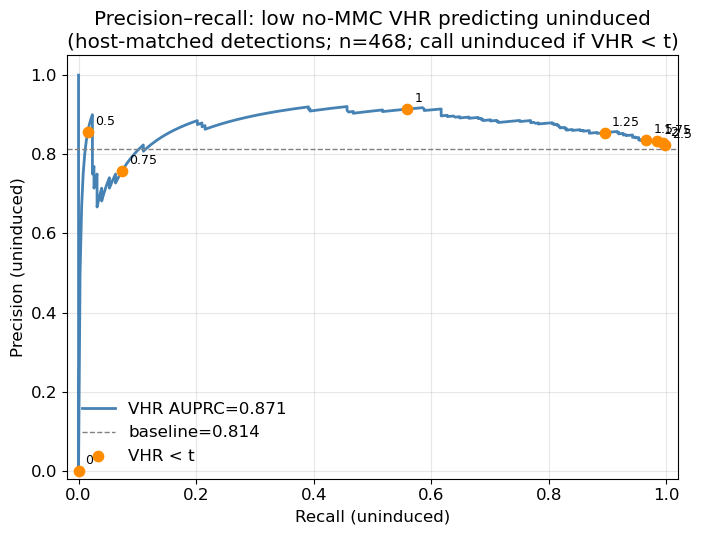

wrote /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/paired_mmc_results/mmc_vhr_precision_recall.png


In [46]:
### VHR precision–recall (predict uninduced)
# Positive class = uninduced (pr_cat == TP). Lower no-MMC VHR → more uninducible.
# Score = -VHR so sklearn PR treats higher scores as positive.
# Discrete points: call uninduced if VHR < threshold.

_vhr_pr = (
    no_mmc_df[["group", "species_cluster_id", "pr_cat", "predicted_inactive_probability"]]
    .copy()
)
_vhr_pr["sample_id"] = _vhr_pr["group"].astype(str) + "_no_mmc"
_vhr_keys = pl.from_pandas(
    _vhr_pr[["sample_id", "group", "species_cluster_id"]].astype(
        {"species_cluster_id": "int64"}
    )
)
_vhr_join = _vhr_keys.join(
    vhr_no_mmc_combined.select(
        [
            "sample_id",
            pl.col("species_cluster_id").cast(pl.Int64),
            pl.col("vhr_cascade").alias("vhr"),
        ]
    ),
    on=["sample_id", "species_cluster_id"],
    how="inner",
)
_tmp_vhr = OUT_DIR / "_tmp_vhr_pr.tsv"
_vhr_join.select(["group", "species_cluster_id", "vhr"]).write_csv(_tmp_vhr, separator="\t")
_vhr_pr = _vhr_pr.merge(pd.read_csv(_tmp_vhr, sep="\t"), on=["group", "species_cluster_id"], how="inner")
_tmp_vhr.unlink(missing_ok=True)
_vhr_pr["y_uninduced"] = (_vhr_pr["pr_cat"] == "TP").astype(int)

y = _vhr_pr["y_uninduced"].to_numpy()
vhr = _vhr_pr["vhr"].to_numpy()
score = -vhr  # higher score = lower VHR = more uninduced
prec_c, rec_c, thr_c = precision_recall_curve(y, score)
auprc_vhr = average_precision_score(y, score)
baseline = float(y.mean())

# Discrete operating points: predict uninduced if VHR < t
thr_rows = []
for t in VHR_THRESHOLDS:
    pred_pos = (vhr < t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y, pred_pos, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y, pred_pos, labels=[0, 1]).ravel()
    thr_rows.append(
        {
            "vhr_threshold": t,
            "rule": f"VHR < {t:g}",
            "n_called": int(pred_pos.sum()),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
        }
    )
vhr_pr_thresholds = pd.DataFrame(thr_rows)
print(
    f"VHR PR (uninduced): n={len(_vhr_pr)} uninduced={int(y.sum())} ({100*baseline:.1f}%) "
    f"AUPRC={auprc_vhr:.3f}"
)
print(vhr_pr_thresholds.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(7.2, 5.5))
ax.plot(rec_c, prec_c, color="steelblue", lw=2, label=f"VHR AUPRC={auprc_vhr:.3f}")
ax.axhline(baseline, color="grey", ls="--", lw=1, label=f"baseline={baseline:.3f}")
ax.scatter(
    vhr_pr_thresholds["recall"],
    vhr_pr_thresholds["precision"],
    c="darkorange",
    s=55,
    zorder=3,
    label="VHR < t",
)
for _, row in vhr_pr_thresholds.iterrows():
    ax.annotate(
        f"{row['vhr_threshold']:g}",
        (row["recall"], row["precision"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9,
    )
ax.set_xlabel("Recall (uninduced)")
ax.set_ylabel("Precision (uninduced)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.set_title(
    "Precision–recall: low no-MMC VHR predicting uninduced\n"
    f"(host-matched detections; n={len(_vhr_pr)}; call uninduced if VHR < t)"
)
ax.legend(loc="lower left", frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_vhr_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

vhr_pr_thresholds.to_csv(OUT_DIR / "mmc_vhr_precision_recall_thresholds.tsv", sep="\t", index=False)
print("wrote", OUT_DIR / "mmc_vhr_precision_recall.png")


In [47]:
### score boxplot by induction status
# Induced = PTH_mmc ≥ 2 (pr_cat FP); Uninduced = PTH_mmc < 2 (TP)
status_order = ["Uninduced", "Induced"]
status_map = {"TP": status_order[0], "FP": status_order[1]}
colors_ind = {status_order[0]: "#E45756", status_order[1]: "#4C78A8"}
plot_df = no_mmc_df.copy()
plot_df["induction_status"] = plot_df["pr_cat"].map(status_map)
data_box = [
    plot_df.loc[plot_df["induction_status"] == s, "predicted_inactive_probability"].to_numpy()
    for s in status_order
]

fig, ax = plt.subplots(figsize=(5.8, 4.2))
positions = [1.0, 2.0]
bp = ax.boxplot(
    data_box,
    positions=positions,
    widths=0.55,
    vert=False,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.3},
    whiskerprops={"color": "black"},
    capprops={"color": "black"},
    boxprops={"linewidth": 0.8},
)
for patch, s in zip(bp["boxes"], status_order):
    patch.set_facecolor(colors_ind[s])
    patch.set_alpha(0.45)

rng = np.random.default_rng(0)
for pos, s, vals in zip(positions, status_order, data_box):
    jitter = (rng.random(len(vals)) - 0.5) * 0.18
    ax.scatter(
        vals,
        np.full(len(vals), pos) + jitter,
        color=colors_ind[s],
        edgecolor="black",
        linewidth=0.4,
        s=28,
        alpha=0.85,
        zorder=3,
    )
    ax.text(1.02, pos, f"n={len(vals)}", ha="left", va="center", fontsize=10)

ax.set_yticks(positions)
ax.set_yticklabels(status_order, fontsize=11)
ax.set_xlabel("Classifier probability")
ax.set_xlim(0, 1.18)
ax.set_title("Classifier score by MMC induction status\n(no-MMC species detections)")
ax.axvline(thr, color="grey", ls="--", lw=1, label=f"p≥{thr:.2f}")
ax.grid(True, axis="x", alpha=0.25)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(OUT_DIR / "mmc_score_by_induction_boxplot.png", dpi=150, bbox_inches="tight")
plt.close(fig)

summary_ind = pd.DataFrame(
    [
        {
            "status": s,
            "n": len(vals),
            "median": float(np.median(vals)) if len(vals) else np.nan,
            "mean": float(np.mean(vals)) if len(vals) else np.nan,
        }
        for s, vals in zip(status_order, data_box)
    ]
)
summary_ind.to_csv(OUT_DIR / "mmc_score_by_induction_summary.tsv", sep="\t", index=False)
print(summary_ind.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


   status   n  median  mean
Uninduced 384   0.812 0.769
  Induced 105   0.668 0.630


In [48]:
### breadth_ratio + complete_count boxplots by induction status
# Uninduced = PTH_mmc < 2 (TP); Induced = PTH_mmc ≥ 2 (FP)
# Note: feature column is complete_count (UHVDB genomovar completeness count)
status_order = ["Uninduced (PTH_mmc<2)", "Induced (PTH_mmc≥2)"]
status_map = {"TP": status_order[0], "FP": status_order[1]}
colors_ind = {status_order[0]: "#E45756", status_order[1]: "#4C78A8"}

feat_df = no_mmc_df.copy()
feat_df["induction_status"] = feat_df["pr_cat"].map(status_map)
feat_df = feat_df.dropna(subset=["induction_status"])

metrics_to_plot = [
    ("breadth_ratio", "breadth_ratio"),
    ("complete_count", "complete_count"),
]
for col, _ in metrics_to_plot:
    if col not in feat_df.columns:
        raise KeyError(f"Missing column {col} in no_mmc_df")

summary_rows = []
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
rng = np.random.default_rng(1)

for ax, (col, ylabel) in zip(axes, metrics_to_plot):
    data_box = [
        feat_df.loc[feat_df["induction_status"] == s, col].dropna().to_numpy(dtype=float)
        for s in status_order
    ]
    positions = [1.0, 2.0]
    bp = ax.boxplot(
        data_box,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.3},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        boxprops={"linewidth": 0.8},
    )
    for patch, s in zip(bp["boxes"], status_order):
        patch.set_facecolor(colors_ind[s])
        patch.set_alpha(0.45)

    nonempty = [v for v in data_box if len(v)]
    ymax = float(np.nanmax(np.concatenate(nonempty))) if nonempty else 1.0
    ymin = float(np.nanmin(np.concatenate(nonempty))) if nonempty else 0.0
    for pos, s, vals in zip(positions, status_order, data_box):
        if len(vals) == 0:
            continue
        jitter = (rng.random(len(vals)) - 0.5) * 0.18
        ax.scatter(
            np.full(len(vals), pos) + jitter,
            vals,
            color=colors_ind[s],
            edgecolor="black",
            linewidth=0.4,
            s=22,
            alpha=0.75,
            zorder=3,
        )
        ax.text(pos, ymax * 1.05, f"n={len(vals)}", ha="center", va="bottom", fontsize=10)
        summary_rows.append(
            {
                "metric": col,
                "status": s,
                "n": len(vals),
                "median": float(np.median(vals)),
                "mean": float(np.mean(vals)),
                "q25": float(np.percentile(vals, 25)),
                "q75": float(np.percentile(vals, 75)),
            }
        )

    ax.set_xticks(positions)
    ax.set_xticklabels([s.replace(" (", "\n(") for s in status_order], fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(0.0, ymin), ymax * 1.18)
    ax.grid(True, axis="y", alpha=0.25)

fig.suptitle(
    "Feature values by MMC induction status\n(no-MMC species detections; labels from PTH in MMC)",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
out_png = OUT_DIR / "mmc_breadth_ratio_complete_count_by_induction_boxplot.png"
fig.savefig(out_png, dpi=150, bbox_inches="tight")
plt.close(fig)

summary_feat = pd.DataFrame(summary_rows)
summary_feat.to_csv(
    OUT_DIR / "mmc_breadth_ratio_complete_count_by_induction_summary.tsv",
    sep="\t",
    index=False,
)
print(summary_feat.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("wrote:", out_png)


        metric                status   n  median  mean   q25   q75
 breadth_ratio Uninduced (PTH_mmc<2) 384   0.740 0.678 0.478 0.855
 breadth_ratio   Induced (PTH_mmc≥2) 105   0.813 0.771 0.698 0.917
complete_count Uninduced (PTH_mmc<2) 384   0.000 1.362 0.000 0.000
complete_count   Induced (PTH_mmc≥2) 105   0.000 1.390 0.000 1.000
wrote: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/paired_mmc_results/mmc_breadth_ratio_complete_count_by_induction_boxplot.png


In [49]:
### write TSVs + summary JSON
# Save tables
no_mmc_feat.write_csv(OUT_DIR / "mmc_no_mmc_features.tsv", separator="\t")
no_mmc_df.to_csv(OUT_DIR / "mmc_no_mmc_predictions.tsv", sep="\t", index=False)
mmc_pred.to_csv(OUT_DIR / "mmc_mmc_predictions.tsv", sep="\t", index=False)
metrics.to_csv(OUT_DIR / "mmc_classifier_metrics.tsv", sep="\t", index=False)
by_group.to_csv(OUT_DIR / "mmc_classifier_by_group.tsv", sep="\t", index=False)
prop_called.to_csv(OUT_DIR / "mmc_prop_called.tsv", sep="\t", index=False)
pd.concat(curve_rows, ignore_index=True).to_csv(
    OUT_DIR / "mmc_vhr_enrichment_curves.tsv", sep="\t", index=False
)
combined.write_csv(OUT_DIR / "mmc_vhr_combined.tsv", separator="\t")
by_vhr_bin.to_csv(OUT_DIR / "mmc_metrics_by_vhr_bin.tsv", sep="\t", index=False)

summary = {
    "pairs": pairs,
    "threshold": thr,
    "ictv_class_filter": ICTV_CLASS_FILTER,
    "n_features": len(numeric_cols),
    "feature_set": meta.get("feature_set"),
    "learner": meta.get("learner"),
    "n_no_mmc": int(len(no_mmc_df)),
    "n_tp": int((no_mmc_df["pr_cat"] == "TP").sum()),
    "n_fp": int((no_mmc_df["pr_cat"] == "FP").sum()),
    "auroc": float(auroc),
    "auprc": float(auprc),
    "precision_at_thresh": float(metrics.loc[metrics["threshold_name"] == "thresh_90", "precision"].iloc[0]),
    "recall_at_thresh": float(metrics.loc[metrics["threshold_name"] == "thresh_90", "recall"].iloc[0]),
    "mean_feature_null_frac": float(null_frac),
}
(OUT_DIR / "mmc_summary.json").write_text(json.dumps(summary, indent=2))
print("Wrote outputs to", OUT_DIR)
print(json.dumps(summary, indent=2))


Wrote outputs to /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/mmc_activity_analysis/paired_mmc_results
{
  "pairs": [
    "cc_CC00005",
    "cc_CC00009",
    "cc_CC00010",
    "cc_CC00012",
    "cc_CC00013",
    "cc_CC00015",
    "cc_CC00016",
    "cc_CC00017",
    "cc_CC00028",
    "cc_CC00029",
    "cc_CC00033",
    "cc_CC00048",
    "cc_CC00049",
    "cc_CC00051",
    "cc_CC00054",
    "cc_CC00055",
    "cc_CC00057",
    "cc_CC00065",
    "cc_CC00067",
    "cc_CC00071",
    "cc_CC00081",
    "cc_CC00086",
    "cc_CC00087",
    "cc_CC00113",
    "cc_CC00118",
    "cc_CC00119",
    "cc_CC00122",
    "cc_CC00129",
    "cc_CC00134",
    "cc_CC00172",
    "cc_CC00178",
    "cc_CC00191",
    "cc_CC00237",
    "cc_CC00254",
    "cc_CC00533",
    "cc_CC00536",
    "cc_CC00546",
    "cc_CC00549",
    "cc_CC00565",
    "cc_CC00568",
    "cc_CC00586",
    "cc_CC00595",
    "cc_CC00596",
    "cc_CC00795",
    "cc_CC00806",
    "cc_CC00870",
    "cc_CC

### Summary
- **Pairs:** cc_CC00005, cc_CC00009, cc_CC00010, cc_CC00012, cc_CC00013, cc_CC00015, cc_CC00016, cc_CC00017, cc_CC00028, cc_CC00029, cc_CC00033, cc_CC00048, cc_CC00049, cc_CC00051, cc_CC00054, cc_CC00055, cc_CC00057, cc_CC00065, cc_CC00067, cc_CC00071, cc_CC00081, cc_CC00086, cc_CC00087, cc_CC00113, cc_CC00118, cc_CC00119, cc_CC00122, cc_CC00129, cc_CC00134, cc_CC00172, cc_CC00178, cc_CC00191, cc_CC00237, cc_CC00254, cc_CC00533, cc_CC00536, cc_CC00546, cc_CC00549, cc_CC00565, cc_CC00568, cc_CC00586, cc_CC00595, cc_CC00596, cc_CC00795, cc_CC00806, cc_CC00870, cc_CC01024, cc_CC01266, cc_CC01373, cc_CC01374, cc_CC01382, cc_CC01397, cc_CC01399, cc_CC01400, cc_CC01408, cc_CC01412, cc_CC01413, cc_CC01415, cc_CC01416, cc_CC01417, cc_CC01418, cc_CC01419, cc_CC01420, cc_CC01421, cc_CC01422, cc_CC01425, cc_CC01426, cc_CC01427, cc_CC01428, cc_CC01430, cc_CC01431, cc_CC01432, cc_CC01433, cc_CC01437, liang_B3451, liang_B3754, liang_E3404, liang_L3400, liang_L3404, liang_L3570, liang_L3651, liang_L3654, liang_L3754, liang_L3891, liang_L3894, liang_L3951, liang_L3954, liang_L3981, liang_L3984, liang_L4281, mvirs_HS, mvirs_I46, mvirs_I48, mvirs_KB18, mvirs_LT2p22, mvirs_YL31, mvirs_YL32, mvirs_YL44
- **Threshold:** p ≥ 0.87
- **AUROC / AUPRC:** 0.678 / 0.873
- **Precision / recall @ thresh:** 0.898 / 0.414
- **Mean feature null frac:** 0.001


**mmc_pr_roc.png**

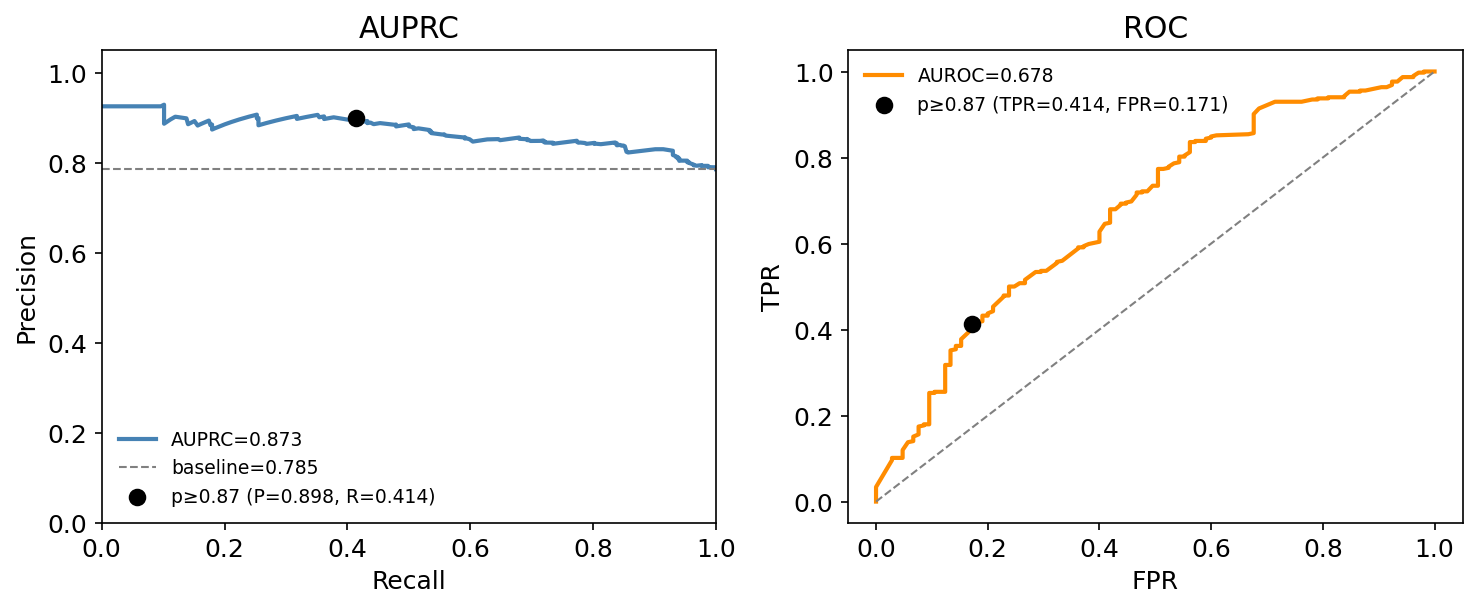

**mmc_score_distributions.png**

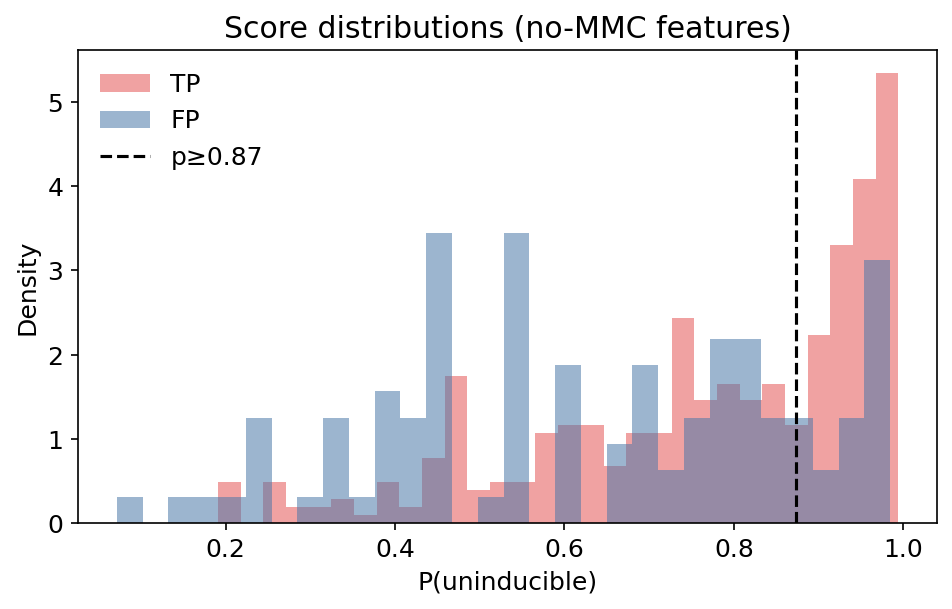

**mmc_score_by_induction_boxplot.png**

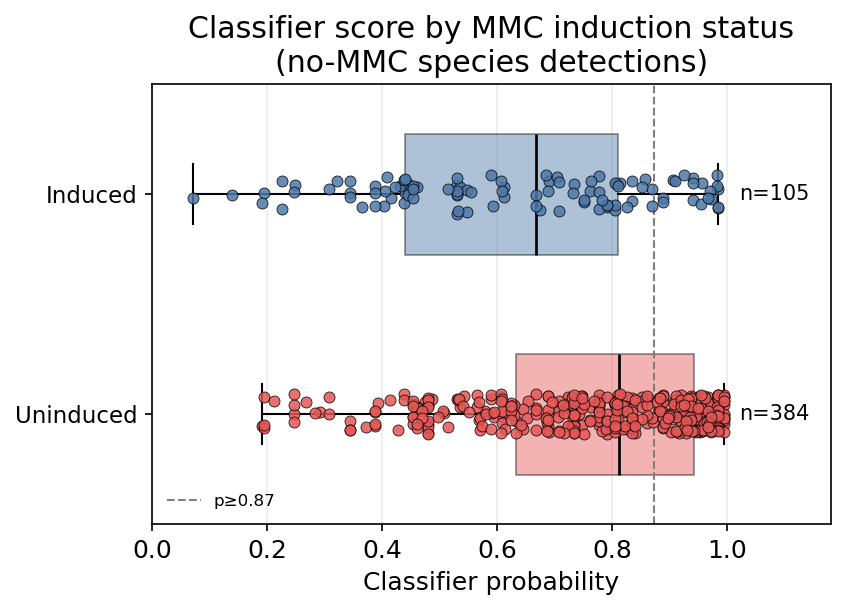

**mmc_breadth_ratio_complete_count_by_induction_boxplot.png**

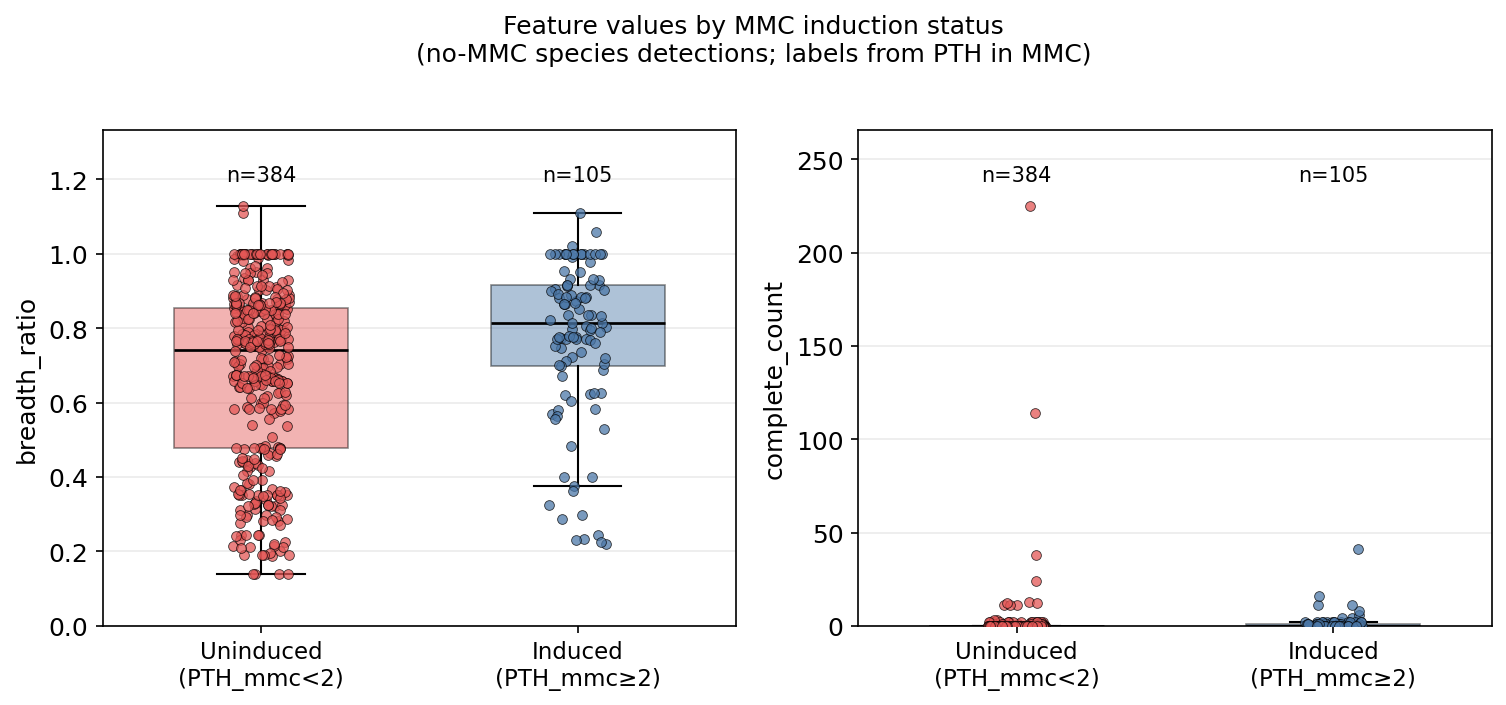

**mmc_prop_called.png**

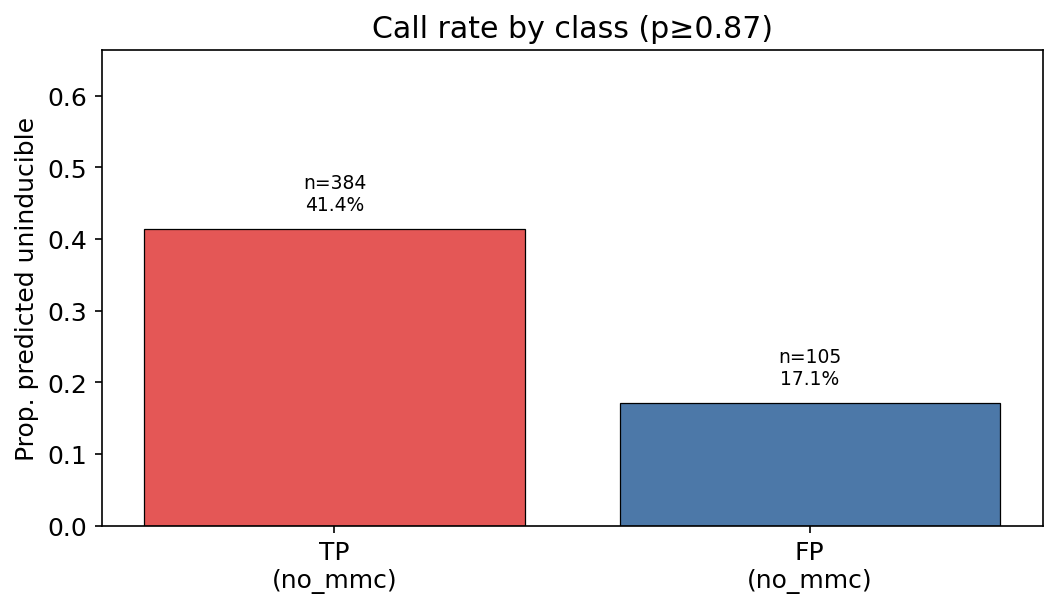

**mmc_tp_vs_fp_stacked_by_sample.png**

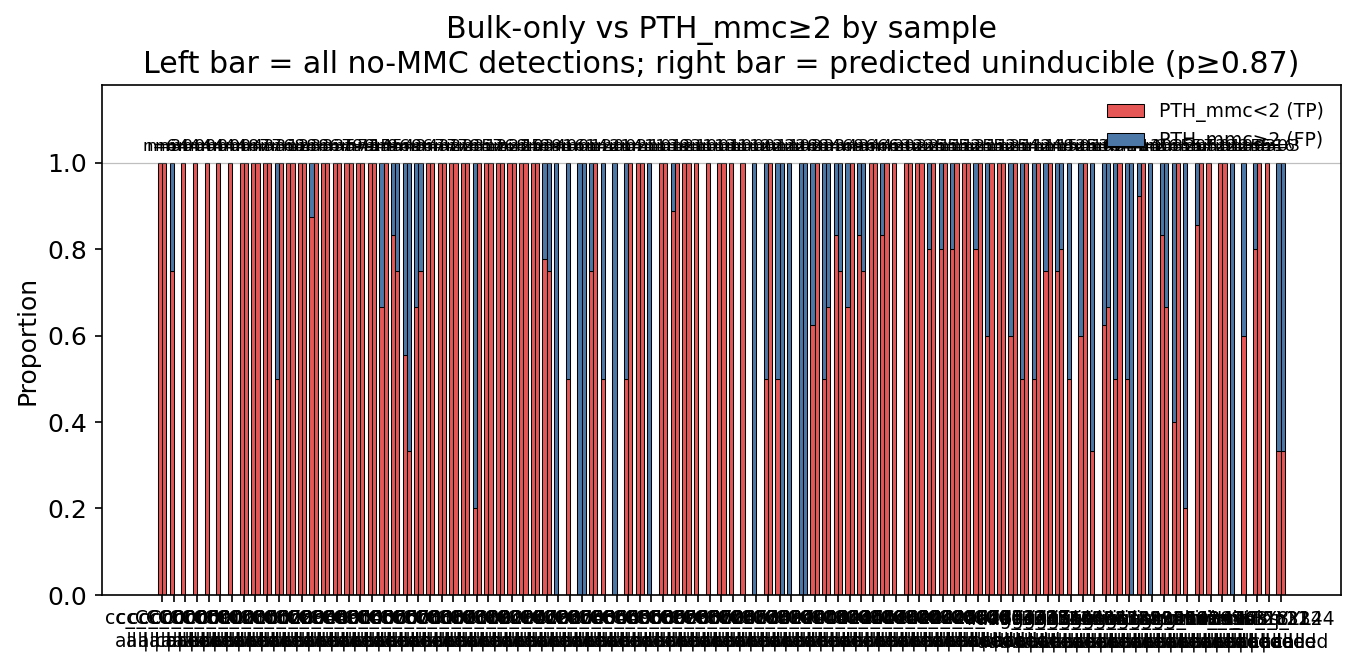

**mmc_tp_vs_fp_pre_post_filter.png**

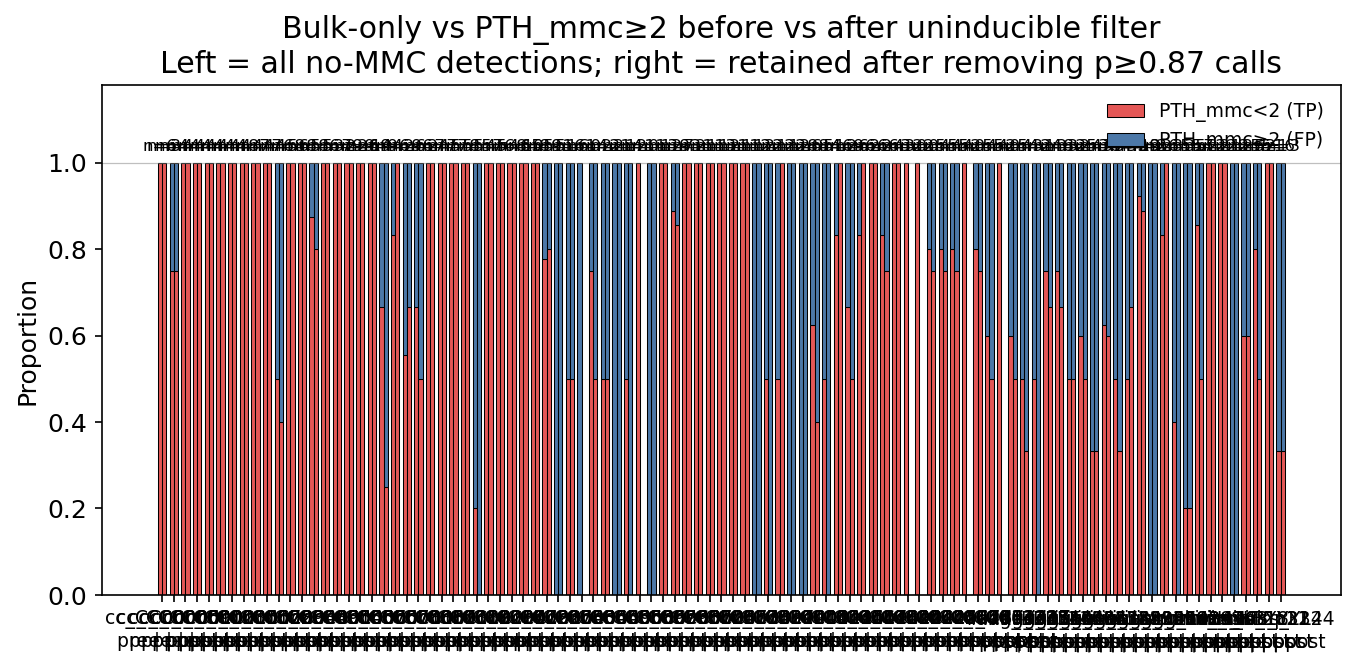

**mmc_pre_post_filter_boxplot.png**

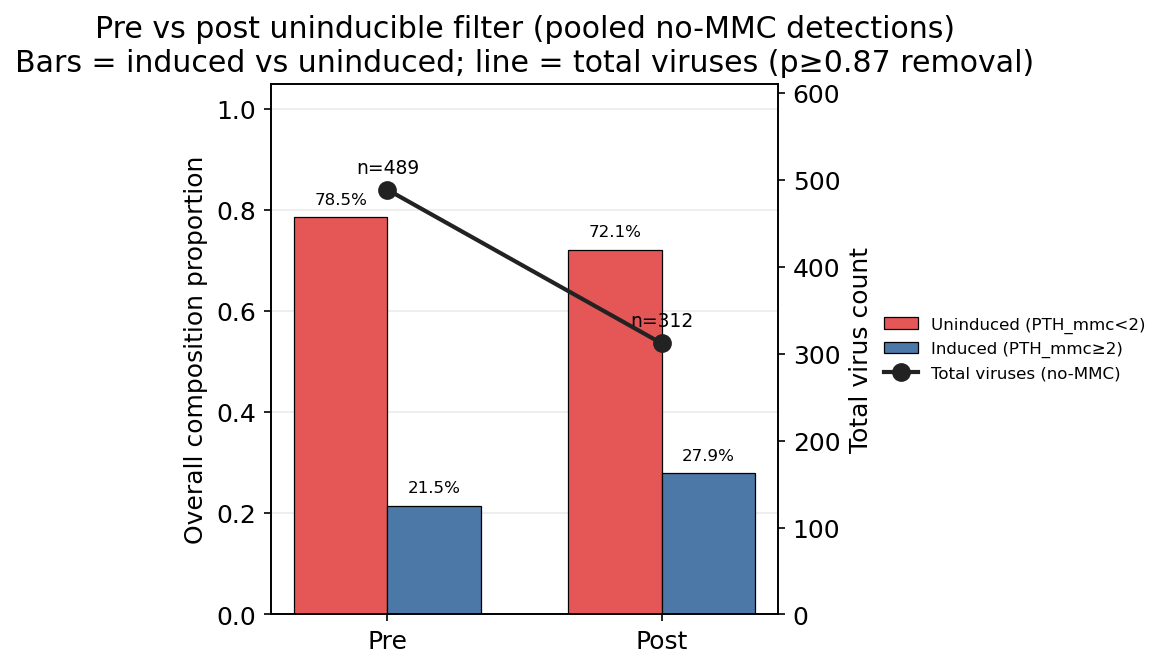

**mmc_vhr_cascade_pre_post.png**

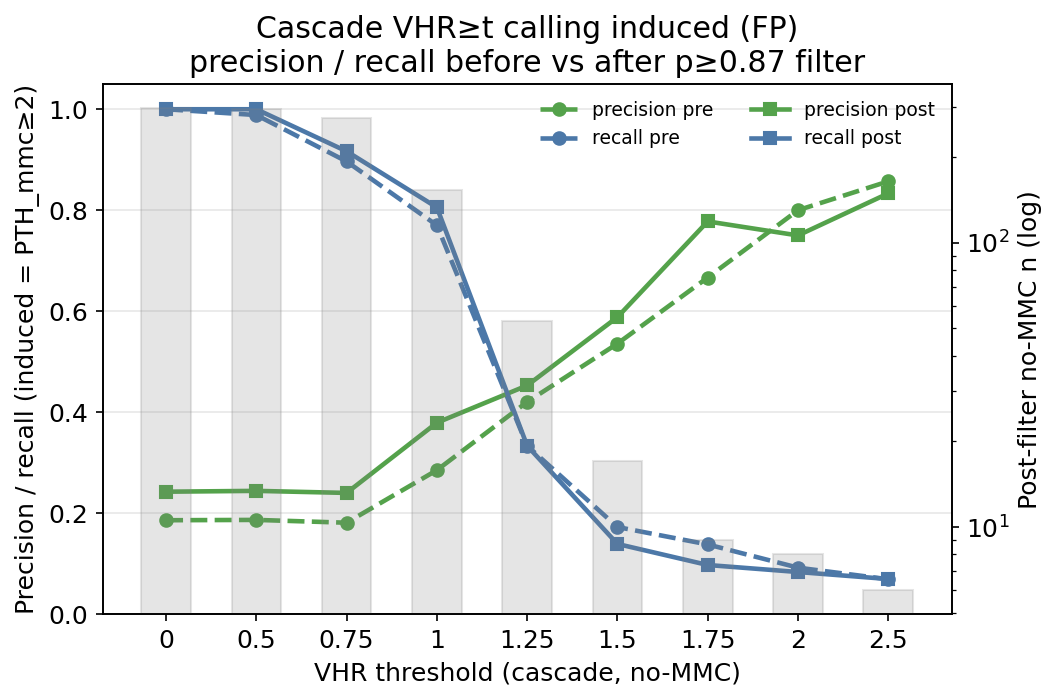

**mmc_vhr_precision_recall.png**

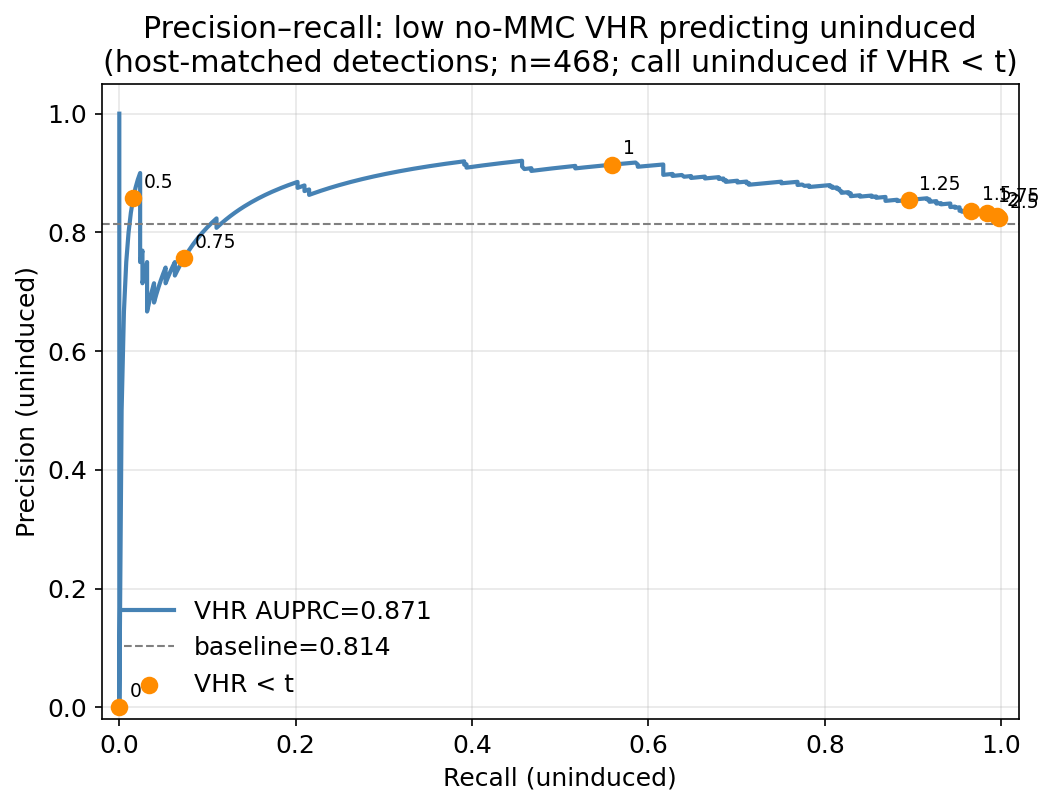

In [50]:
### display key outputs
from IPython.display import display, Image, Markdown
import json

summary = json.loads((OUT_DIR / "mmc_summary.json").read_text())
display(Markdown(f"""### Summary
- **Pairs:** {', '.join(summary['pairs'])}
- **Threshold:** p ≥ {summary['threshold']:.2f}
- **AUROC / AUPRC:** {summary['auroc']:.3f} / {summary['auprc']:.3f}
- **Precision / recall @ thresh:** {summary['precision_at_thresh']:.3f} / {summary['recall_at_thresh']:.3f}
- **Mean feature null frac:** {summary['mean_feature_null_frac']:.3f}
"""))
for name in [
    "mmc_pr_roc.png",
    "mmc_score_distributions.png",
    "mmc_score_by_induction_boxplot.png",
    "mmc_breadth_ratio_complete_count_by_induction_boxplot.png",
    "mmc_prop_called.png",
    "mmc_tp_vs_fp_stacked_by_sample.png",
    "mmc_tp_vs_fp_pre_post_filter.png",
    "mmc_pre_post_filter_boxplot.png",
    "mmc_vhr_cascade_pre_post.png",
    "mmc_vhr_precision_recall.png",
]:
    display(Markdown(f"**{name}**"))
    display(Image(filename=str(OUT_DIR / name)))